In [ ]:
# !pip uninstall -y kaleido
# !pip install kaleido==0.2.1
# !pip install pwlf scikit-learn pandas numpy plotly scipy
# !pip install shap

# After installation, restart the session

# Data preparation and graph generators

## Data preparation
1. Import data from file
1. Transform data
2. Generate additional columns
3. Create filters

In [2]:
filename = 'openbenchmarking - export.csv'

basepath = '../03_data/'

filepath = basepath + filename

In [3]:
import pandas as pd
import numpy as np
from typing import List, Optional, Union
import os
import plotly.graph_objects as go

class BenchmarkDataProcessor:
    def __init__(
        self,
        filepath: str,
        fp4_mult: float = 1,
        fp8_mult: float = 1,
        fp16_mult: float = 1,
        fp32_mult: float = 1,
        fp64_mult: float = 1,
        packets: Optional[Union[str, List[str]]] = None,
        benchmarks: Optional[Union[str, List[str]]] = None,
        processor_filter_keywords: Optional[List[str]] = None,
        processors_to_remove: Optional[List[str]] = None,
        min_price: Optional[float] = None,
        max_price: Optional[float] = None,
        nyears: int = 5,
        ecost_kwh: float = 0.118,
        power_column: str = 'Base TDP. W'
    ):
        """
        Class for processing benchmark data

        Args:
            filepath (str): Path to CSV file with data
            fp4_mult, fp8_mult, ...: Correction multipliers for GFLOPS
            packets (list/str/None): Limit analysis to these packets only.
            benchmarks (list/str/None): Limit analysis to these benchmarks only.
            processor_filter_keywords (list/None): List of keywords for processor filtering.
            processors_to_remove (list/None): List of keywords for removing processors.
            min_price (float/None): Minimum price for filtering (inclusive).
            max_price (float/None): Maximum price for filtering (inclusive).
            nyears: int = 5,                 # CPU depreciation period (years)
            ecost_kwh: float = 0.118,        # Electricity cost per kWh (USD, estimated)
            power_column: str = 'Base TDP, W'    # Name of the TDP column
        """
        pd.options.mode.chained_assignment = None

        self.fp4_mult = fp4_mult
        self.fp8_mult = fp8_mult
        self.fp16_mult = fp16_mult
        self.fp32_mult = fp32_mult
        self.fp64_mult = fp64_mult

        # Filtering parameters
        self.packets = self._to_list(packets)
        self.benchmarks = self._to_list(benchmarks)
        self.processor_filter_keywords = processor_filter_keywords or [
            'Intel Atom', 'Intel Pentium', 'Intel Celeron', 'Intel Core',
            'Intel Xeon', 'Apple', 'Ampere', 'ARM', 'AMD Athlon', 'AMD EPYC',
            'AMD Ryzen', 'AMD Opteron', '2 x AMD', '2 x Intel', '4 x '
        ]
        self.processors_to_remove = processors_to_remove or [
            'Apple', 'Ampere', 'ARM'
        ]
        self.min_price = min_price
        self.max_price = max_price
        self.nyears = nyears
        self.ecost_kwh = ecost_kwh
        self.power_column = power_column
        self.price_column = 'Price.$'

        # Read data
        self.df = pd.read_csv(filepath)

        # Convert price to numeric (if exists)
        if 'Price.$' in self.df.columns:
            self.df['Price.$'] = pd.to_numeric(self.df['Price.$'], errors='coerce')
        else:
            self.df['Price.$'] = np.nan

        # Remove processors by list
        self._remove_processor_rows()

        # Create processor filter
        self._create_processors_filter()

        # Initialize variables
        self.X_AXIS_PARAM = None
        self.USE_ALL_VALUES = None
        self.X_AXIS_RANGE = None

        # Features for analysis
        self.features = [
            'Natoms*ns/day', 'CPU MHz', 'Cache L3. KB', 'Cache L2. KB',
            'Cores', 'Threads', 'Mem Bandwidth. GB/s', 'GFLOPS',
            'Mem Channels', 'Price.$'
        ]

        # Convert to numeric
        for col in self.features:
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

        # Drop rows with NaN in key columns
        key_cols = [col for col in self.features if col in self.df.columns]
        self.df = self.df.dropna(subset=key_cols)

        # GFLOPS correction
        self._apply_fp_correction()

        # Future data
        self.X = None
        self.filter_values = {}

    # ----------------------------------------------------------------------
    # Helper methods
    # ----------------------------------------------------------------------
    @staticmethod
    def _to_list(value: Optional[Union[str, List[str]]]) -> Optional[List[str]]:
        if value is None:
            return None
        if isinstance(value, str):
            return [value]
        return value

    def _apply_packets_benchmarks_filter(self):
        """Filter by packets and benchmarks"""
        if self.packets is not None and 'Packet' in self.df.columns:
            self.df = self.df[self.df['Packet'].isin(self.packets)]
        if self.benchmarks is not None and 'Benchmark' in self.df.columns:
            self.df = self.df[self.df['Benchmark'].isin(self.benchmarks)]

    def _apply_price_filter(self):
        """Filter by price"""
        if self.min_price is not None:
            self.df = self.df[self.df['Price.$'] >= self.min_price]
        if self.max_price is not None:
            self.df = self.df[self.df['Price.$'] <= self.max_price]

    def _apply_fp_correction(self):
        """GFLOPS correction based on wiki FP32"""
        mask = self.df['wiki FP32'] == 4
        self.df.loc[mask, 'GFLOPS'] = self.df.loc[mask, 'GFLOPS'] / self.fp4_mult

        mask = self.df['wiki FP32'] == 8
        self.df.loc[mask, 'GFLOPS'] = self.df.loc[mask, 'GFLOPS'] / self.fp8_mult

        mask = self.df['wiki FP32'] == 16
        self.df.loc[mask, 'GFLOPS'] = self.df.loc[mask, 'GFLOPS'] / self.fp16_mult

        mask = self.df['wiki FP32'] == 32
        self.df.loc[mask, 'GFLOPS'] = self.df.loc[mask, 'GFLOPS'] / self.fp32_mult

        mask = self.df['wiki FP32'] == 64
        self.df.loc[mask, 'GFLOPS'] = self.df.loc[mask, 'GFLOPS'] / self.fp64_mult

    def _create_processors_filter(self):
        """Create processor_filter column based on keywords"""
        self.df['processor_filter'] = 'reference'
        for keyword in self.processor_filter_keywords:
            mask = self.df['Component'].astype(str).str.contains(keyword, case=False, na=False, regex=True)
            self.df.loc[mask, 'processor_filter'] = keyword
        self.df['market_filter'] = self.df['Market'].astype(str).str.strip()

    def _remove_processor_rows(self):
        """Remove rows with processors from processors_to_remove list"""
        for keyword in self.processors_to_remove:
            mask = self.df['Component'].astype(str).str.contains(keyword, case=False, na=False, regex=True)
            self.df = self.df[~mask]

    # ----------------------------------------------------------------------
    # Categorization methods
    # ----------------------------------------------------------------------
    def _categorize_price(self, price):
        """Price categorization"""
        if pd.isna(price):
            return 'No price'
        try:
            p = float(price)
            if p == 0.01:
                return 'No price'
            elif p < 100:
                return '<$100'
            elif p < 500:
                return '$100-500'
            elif p < 1000:
                return '$500-1000'
            elif p < 2000:
                return '$1000-2000'
            elif p < 5000:
                return '$2000-5000'
            elif p < 10000:
                return '$5000-10000'
            elif p < 20000:
                return '$10000-20000'
            else:
                return '>$20000'
        except:
            return 'Unknown'

    def _categorize_x_param(self, value):
        """Categorization for the selected X-axis parameter"""
        if pd.isna(value) or value == '':
            return 'Unknown'
        try:
            val = float(value)
            if self.X_AXIS_PARAM == 'GFLOPS':
                if val < 100:
                    return '<100'
                elif val < 500:
                    return '100-500'
                elif val < 1000:
                    return '500-1000'
                elif val < 2000:
                    return '1-2K'
                elif val < 5000:
                    return '2-5K'
                else:
                    return '>5K'
            elif self.X_AXIS_PARAM == 'CPU MHz':
                if val < 2000:
                    return '<2 GHz'
                elif val < 3000:
                    return '2-3 GHz'
                elif val < 4000:
                    return '3-4 GHz'
                elif val < 5000:
                    return '4-5 GHz'
                else:
                    return '>5 GHz'
            elif self.X_AXIS_PARAM == 'Mem Bandwidth. GB/s':
                if val < 10:
                    return '<10 GB/s'
                elif val < 25:
                    return '10-25 GB/s'
                elif val < 50:
                    return '25-50 GB/s'
                elif val < 100:
                    return '50-100 GB/s'
                elif val < 200:
                    return '100-200 GB/s'
                else:
                    return '>200 GB/s'
            elif self.X_AXIS_PARAM == 'Price.$':
                return self._categorize_price(val)
            elif self.X_AXIS_PARAM in ['Cores', 'Threads']:
                val_int = int(val)
                if val_int <= 4:
                    return '1-4'
                elif val_int <= 8:
                    return '5-8'
                elif val_int <= 16:
                    return '9-16'
                elif val_int <= 32:
                    return '17-32'
                elif val_int <= 48:
                    return '33-48'
                else:
                    return '49+'
            elif self.X_AXIS_PARAM in ['Cache L3. KB', 'Cache L2. KB']:
                val_mb = val / 1024
                if self.X_AXIS_PARAM == 'Cache L3. KB':
                    if val_mb < 8:
                        return '<8 MB'
                    elif val_mb < 32:
                        return '8-32 MB'
                    elif val_mb < 128:
                        return '32-128 MB'
                    elif val_mb < 256:
                        return '128-256 MB'
                    else:
                        return '>256 MB'
                else:
                    if val_mb < 1:
                        return '<1 MB'
                    elif val_mb < 8:
                        return '1-8 MB'
                    elif val_mb < 32:
                        return '8-32 MB'
                    elif val_mb < 128:
                        return '32-128 MB'
                    else:
                        return '>128 MB'
            else:
                q25 = np.percentile(self.df[self.X_AXIS_PARAM].dropna(), 25)
                q50 = np.percentile(self.df[self.X_AXIS_PARAM].dropna(), 50)
                q75 = np.percentile(self.df[self.X_AXIS_PARAM].dropna(), 75)
                if val < q25:
                    return f'<{q25:.0f}'
                elif val < q50:
                    return f'{q25:.0f}-{q50:.0f}'
                elif val < q75:
                    return f'{q50:.0f}-{q75:.0f}'
                else:
                    return f'>{q75:.0f}'
        except:
            return 'Unknown'

    def _categorize_cpu_frequency(self, freq):
        if pd.isna(freq):
            return 'Unknown'
        try:
            freq_val = float(freq)
            if freq_val < 2000:
                return '<2 GHz'
            elif freq_val < 3000:
                return '2-3 GHz'
            elif freq_val < 4000:
                return '3-4 GHz'
            elif freq_val < 5000:
                return '4-5 GHz'
            else:
                return '>5 GHz'
        except:
            return 'Unknown'

    def _categorize_memory_bandwidth(self, bw):
        if pd.isna(bw):
            return 'Unknown'
        try:
            bw_val = float(bw)
            if bw_val < 10:
                return '<10 GB/s'
            elif bw_val < 25:
                return '10-25 GB/s'
            elif bw_val < 50:
                return '25-50 GB/s'
            elif bw_val < 100:
                return '50-100 GB/s'
            elif bw_val < 200:
                return '100-200 GB/s'
            else:
                return '>200 GB/s'
        except:
            return 'Unknown'

    def _categorizeCores(self, cores):
        if pd.isna(cores):
            return 'Unknown'
        try:
            cores_val = int(cores)
            if cores_val <= 4:
                return '1-4 cores'
            elif cores_val <= 8:
                return '5-8 cores'
            elif cores_val <= 16:
                return '9-16 cores'
            elif cores_val <= 32:
                return '17-32 cores'
            elif cores_val <= 48:
                return '33-48 cores'
            else:
                return '49+ cores'
        except:
            return 'Unknown'

    def _categorizeThreads(self, threads):
        if pd.isna(threads):
            return 'Unknown'
        try:
            threads_val = int(threads)
            if threads_val <= 8:
                return '1-8 threads'
            elif threads_val <= 16:
                return '9-16 threads'
            elif threads_val <= 32:
                return '17-32 threads'
            elif threads_val <= 64:
                return '33-64 threads'
            else:
                return '65+ threads'
        except:
            return 'Unknown'

    def _categorizeThreadsCores_ratio(self, row):
        if pd.isna(row['Threads']) or pd.isna(row['Cores']) or row['Cores'] == 0:
            return 'Unknown'
        try:
            ratio = row['Threads'] / row['Cores']
            if ratio <= 1:
                return '≤1 (1 thread/core)'
            elif ratio <= 1.5:
                return '1-1.5'
            elif ratio <= 2:
                return '1.5-2'
            else:
                return '>2'
        except:
            return 'Unknown'

    def _categorize_l3_cache(self, l3):
        if pd.isna(l3):
            return 'Unknown'
        try:
            l3_val = float(l3)
            l3_mb = l3_val / 1024
            if l3_mb < 8:
                return '<8 MB'
            elif l3_mb < 32:
                return '8-32 MB'
            elif l3_mb < 128:
                return '32-128 MB'
            elif l3_mb < 256:
                return '128-256 MB'
            else:
                return '>256 MB'
        except:
            return 'Unknown'

    def _categorize_l2_cache(self, l2):
        if pd.isna(l2):
            return 'Unknown'
        try:
            l2_val = float(l2)
            l2_mb = l2_val / 1024
            if l2_mb < 1:
                return '<1 MB'
            elif l2_mb < 8:
                return '1-8 MB'
            elif l2_mb < 32:
                return '8-32 MB'
            elif l2_mb < 128:
                return '32-128 MB'
            else:
                return '>128 MB'
        except:
            return 'Unknown'

    def _categorize_l2_l3_ratio(self, row):
        if pd.isna(row['Cache L2. KB']) or pd.isna(row['Cache L3. KB']) or row['Cache L3. KB'] == 0:
            return 'Unknown'
        try:
            l2_kb = float(row['Cache L2. KB'])
            l3_kb = float(row['Cache L3. KB'])
            ratio = l2_kb / l3_kb
            if ratio < 0.1:
                return '<0.1'
            elif ratio < 0.3:
                return '0.1-0.3'
            elif ratio < 0.5:
                return '0.3-0.5'
            else:
                return '>0.5'
        except:
            return 'Unknown'

    def _categorize_memory_channels(self, channels):
        if pd.isna(channels):
            return 'Unknown'
        try:
            channels_val = int(channels)
            if channels_val == 1:
                return '1 channel'
            elif channels_val == 2:
                return '2 channels'
            elif channels_val == 4:
                return '4 channels'
            elif channels_val == 6:
                return '6 channels'
            elif channels_val == 8:
                return '8 channels'
            elif channels_val == 12:
                return '12 channels'
            elif channels_val == 16:
                return '16 channels'
            else:
                return f'{channels_val}+ channels'
        except:
            return 'Unknown'

    def _categorize_l3_per_core(self, l3_per_core):
        if pd.isna(l3_per_core) or l3_per_core == 0:
            return 'Unknown'
        try:
            l3_per_core_val = float(l3_per_core)
            l3_per_core_mb = l3_per_core_val / 1024
            if l3_per_core_mb < 1:
                return '<1 MB/core'
            elif l3_per_core_mb < 2:
                return '1-2 MB/core'
            elif l3_per_core_mb < 4:
                return '2-4 MB/core'
            elif l3_per_core_mb < 8:
                return '4-8 MB/core'
            else:
                return '>8 MB/core'
        except:
            return 'Unknown'

    def _categorize_wiki_fp32(self, value):
        if pd.isna(value):
            return 'Unknown'
        try:
            val = int(value)
            if val == 4:
                return '4 fp32'
            elif val == 8:
                return '8 fp32'
            elif val == 16:
                return '16 fp32'
            elif val == 32:
                return '32 fp32'
            elif val == 64:
                return '64 fp32'
            else:
                return f'{val}+ fp32'
        except:
            return 'Unknown'

    def _categorize_gflops(self, gflops):
        if pd.isna(gflops):
            return 'Unknown'
        try:
            val = float(gflops)
            if val < 100:
                return '<100'
            elif val < 500:
                return '100-500'
            elif val < 1000:
                return '500-1000'
            elif val < 2000:
                return '1-2K'
            elif val < 5000:
                return '2-5K'
            else:
                return '>5K'
        except:
            return 'Unknown'

    def _categorize_perf_per_dollar(self, value):
        """Categorization for performance_per_dollar"""
        if pd.isna(value):
            return 'Unknown'
        try:
            v = float(value)
            if v < 100:
                return '<100'
            elif v < 500:
                return '100-500'
            elif v < 1000:
                return '500-1000'
            elif v < 5000:
                return '1K-5K'
            elif v < 10000:
                return '5K-10K'
            else:
                return '>10K'
        except:
            return 'Unknown'

    def _categorize_adj_cost(self, value):
        """Categorization for adjusted_cost_per_ns_atom"""
        if pd.isna(value):
            return 'Unknown'
        try:
            v = float(value)
            if v < 1e-6:
                return '<1e-6'
            elif v < 5e-6:
                return '1e-6 - 5e-6'
            elif v < 1e-5:
                return '5e-6 - 1e-5'
            elif v < 5e-5:
                return '1e-5 - 5e-5'
            elif v < 1e-4:
                return '5e-5 - 1e-4'
            else:
                return '>1e-4'
        except:
            return 'Unknown'

    # ----------------------------------------------------------------------
    # Apply all filters
    # ----------------------------------------------------------------------
    def apply_all_filters(self):
        """Create all categorical columns in self.df"""
        # Filter for X axis
        x_param_filter_name = f'{self.X_AXIS_PARAM}_filter'
        self.df[x_param_filter_name] = self.df[self.X_AXIS_PARAM].apply(self._categorize_x_param)

        # Other filters
        self.df['cpu_freq_filter'] = self.df['CPU MHz'].apply(self._categorize_cpu_frequency)
        self.df['memory_bw_filter'] = self.df['Mem Bandwidth. GB/s'].apply(self._categorize_memory_bandwidth)
        self.df['memory_channels_filter'] = self.df['Mem Channels'].apply(self._categorize_memory_channels)
        self.df['cores_filter'] = self.df['Cores'].apply(self._categorizeCores)
        self.df['threads_filter'] = self.df['Threads'].apply(self._categorizeThreads)
        self.df['threadsCores_ratio_filter'] = self.df.apply(self._categorizeThreadsCores_ratio, axis=1)
        self.df['l3_cache_filter'] = self.df['Cache L3. KB'].apply(self._categorize_l3_cache)
        self.df['l2_cache_filter'] = self.df['Cache L2. KB'].apply(self._categorize_l2_cache)
        self.df['wiki_fp32_filter'] = self.df['wiki FP32'].apply(self._categorize_wiki_fp32)
        self.df['gflops_filter'] = self.df['GFLOPS'].apply(self._categorize_gflops)
        self.df['price_filter'] = self.df['Price.$'].apply(self._categorize_price)
        self.df['perf_per_dollar_filter'] = self.df['performance_per_dollar'].apply(self._categorize_perf_per_dollar)
        self.df['adj_cost_filter'] = self.df['adjusted_cost_per_ns_atom'].apply(self._categorize_adj_cost)

        # Compute L3 per core
        self.df['L3 per core'] = self.df['Cache L3. KB'] / self.df['Cores']
        self.features.append('L3 per core')
        self.df['l3_per_core_filter'] = self.df['L3 per core'].apply(self._categorize_l3_per_core)

    def add_cost_metrics(self):
        """
        Add two new metrics:
        1) performance_per_dollar = Natoms*ns/day / Price.$
        2) adjusted_cost_per_ns_atom = (daily depreciation + daily energy) / (Natoms*ns/day)
        """
        df = self.df
        # 1. Performance per dollar
        price = df['Price.$']
        perf = df['Natoms*ns/day']
        with np.errstate(divide='ignore', invalid='ignore'):
            perf_per_dollar = perf / price
            perf_per_dollar = perf_per_dollar.replace([np.inf, -np.inf], np.nan)
        df['performance_per_dollar'] = perf_per_dollar

        # 2. Energy-adjusted cost per unit work
        # Get power from the specified column
        if self.power_column in df.columns:
            power_w = pd.to_numeric(df[self.power_column], errors='coerce')
        else:
            print(f"Warning: column '{self.power_column}' not found. Energy correction not applied.")
            power_w = np.nan

        daily_amort = price / (self.nyears * 365.0)
        daily_energy = power_w * 24.0 * self.ecost_kwh / 1000.0
        daily_total_cost = daily_amort + daily_energy.fillna(0)  # if TDP missing, use only depreciation

        with np.errstate(divide='ignore', invalid='ignore'):
            adj_cost = daily_total_cost / perf
            adj_cost = adj_cost.replace([np.inf, -np.inf], np.nan)
        df['adjusted_cost_per_ns_atom'] = adj_cost

        # Add new columns to features list
        if 'performance_per_dollar' not in self.features:
            self.features.append('performance_per_dollar')
        if 'adjusted_cost_per_ns_atom' not in self.features:
            self.features.append('adjusted_cost_per_ns_atom')

    # ----------------------------------------------------------------------
    # Data preparation
    # ----------------------------------------------------------------------
    def prepare_data(self, x_axis_param='GFLOPS', use_all_values=True, x_axis_range=None):
        """
        Prepare data for analysis

        Args:
            x_axis_param (str): Parameter for X axis
            use_all_values (bool): Use all values or filter by range
            x_axis_range (tuple): Value range for x_axis_param
        """
        # First filter by packets/benchmarks
        self._apply_packets_benchmarks_filter()

        # Filter by price
        self._apply_price_filter()

        self.X_AXIS_PARAM = x_axis_param
        self.USE_ALL_VALUES = use_all_values
        self.X_AXIS_RANGE = x_axis_range

        self.add_cost_metrics()

        # Apply all categorical filters
        self.apply_all_filters()

        # Select required columns and remove invalid values
        self.X = self.df[self.features].replace('#VALUE!', np.nan).dropna()

        # Filter by X range
        if not self.USE_ALL_VALUES and self.X_AXIS_RANGE:
            min_val, max_val = self.X_AXIS_RANGE
            mask = (self.X[self.X_AXIS_PARAM] >= min_val) & (self.X[self.X_AXIS_PARAM] <= max_val)
            self.X = self.X[mask]
            print(f"Filter applied: {self.X_AXIS_PARAM} from {min_val} to {max_val}")
            print(f"Remaining records: {len(self.X)}")

        # Save filters for display
        x_param_filter_name = f'{self.X_AXIS_PARAM}_filter'
        self.filter_values = {
            'processor_filter': self.df.loc[self.X.index, 'processor_filter'],
            'market_filter': self.df.loc[self.X.index, 'market_filter'],
            'x_param_filter': self.df.loc[self.X.index, x_param_filter_name],
            'market': self.df.loc[self.X.index, 'Market'],
            'cpu_freq_filter': self.df.loc[self.X.index, 'cpu_freq_filter'],
            'memory_bw_filter': self.df.loc[self.X.index, 'memory_bw_filter'],
            'memory_channels_filter': self.df.loc[self.X.index, 'memory_channels_filter'],
            'cores_filter': self.df.loc[self.X.index, 'cores_filter'],
            'threads_filter': self.df.loc[self.X.index, 'threads_filter'],
            'threadsCores_ratio_filter': self.df.loc[self.X.index, 'threadsCores_ratio_filter'],
            'l3_cache_filter': self.df.loc[self.X.index, 'l3_cache_filter'],
            'l2_cache_filter': self.df.loc[self.X.index, 'l2_cache_filter'],
            'l3_per_core_filter': self.df.loc[self.X.index, 'l3_per_core_filter'],
            'gflops_filter': self.df.loc[self.X.index, 'gflops_filter'],
            'price_filter': self.df.loc[self.X.index, 'price_filter'],
            'packet': self.df.loc[self.X.index, 'Packet'],
            'component': self.df.loc[self.X.index, 'Component'],
            'benchmark': self.df.loc[self.X.index, 'Benchmark'],
            'wiki_fp32_filter': self.df.loc[self.X.index, 'wiki_fp32_filter'],
            'microarchitecture': self.df.loc[self.X.index, 'Microarchitecture'],
            'wiki_fp32': self.df.loc[self.X.index, 'wiki FP32'],
            'price': self.df.loc[self.X.index, 'Price.$'],
            'perf_per_dollar_filter': self.df.loc[self.X.index, 'perf_per_dollar_filter'],
            'adj_cost_filter': self.df.loc[self.X.index, 'adj_cost_filter'],
            'Release Date' : self.df.loc[self.X.index, 'Release Date']
        }

    # ----------------------------------------------------------------------
    # Color palette
    # ----------------------------------------------------------------------
    def get_color_sequence(self):
        import plotly.express as px
        return px.colors.qualitative.Alphabet + px.colors.qualitative.Dark24 + px.colors.qualitative.Light24

## Add diagonal lines

In [4]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import pearsonr

def add_diagonal_lines(fig, data, X_AXIS_PARAM, y_axis_param='Natoms*ns/day',
                       diagonal_type='auto'):
    """
    Adds a dashed diagonal through the center of the point cloud.
    The length is determined by the average data range, and the slope (+1 or -1)
    is chosen automatically based on the correlation sign.

    Parameters:
    fig — plotly Figure object
    data — DataFrame with columns X_AXIS_PARAM and y_axis_param
    X_AXIS_PARAM — name of the X-axis column
    y_axis_param — name of the Y-axis column
    diagonal_type — 'auto', 'positive' (slope +1) or 'negative' (slope -1)
    """
    x_data = data[X_AXIS_PARAM]
    y_data = data[y_axis_param]

    mask = np.isfinite(x_data) & np.isfinite(y_data) & (x_data > 0) & (y_data > 0)
    x_clean = x_data[mask]
    y_clean = y_data[mask]

    if len(x_clean) < 2:
        print("Insufficient points to draw diagonal")
        return

    log_x = np.log10(x_clean)
    log_y = np.log10(y_clean)

    center_log_x = np.mean(log_x)
    center_log_y = np.mean(log_y)

    # Determine slope
    if diagonal_type == 'auto':
        corr, _ = pearsonr(log_x, log_y)
        use_positive_slope = corr >= 0
    elif diagonal_type == 'positive':
        use_positive_slope = True
    else:  # 'negative'
        use_positive_slope = False

    # Compute average range (as in the old code)
    avg_log_range = ((log_x.max() - log_x.min()) + (log_y.max() - log_y.min())) / 2

    # Build main diagonal (short segment through the center)
    if use_positive_slope:
        b = center_log_y - center_log_x
        log_x_line = np.array([center_log_x - avg_log_range/2,
                               center_log_x + avg_log_range/2])
        log_y_line = log_x_line + b
    else:
        c = center_log_y + center_log_x
        log_x_line = np.array([center_log_x - avg_log_range/2,
                               center_log_x + avg_log_range/2])
        log_y_line = -log_x_line + c

    x_line = 10**log_x_line
    y_line = 10**log_y_line

    # Main diagonal
    fig.add_trace(go.Scatter(
        x=x_line, y=y_line,
        mode='lines',
        line=dict(dash='dash', color='grey', width=2),
        name='main_diagonal',
        showlegend=False
    ))

    # Auxiliary lines (multipliers 1.5, 2, 3, 4)
    factors = [1.5, 2, 3, 4]

    if use_positive_slope:
        # Lines y = y0 * f and y = y0 / f
        for f in factors:
            # Upper (y_line.max() / f)
            log_y_target = np.log10(y_line.max() / f)
            log_x_target = log_x_line[0] + (log_x_line[1] - log_x_line[0]) * \
                           (log_y_target - log_y_line[0]) / (log_y_line[1] - log_y_line[0])
            x_extra = [x_line[0], 10**log_x_target]
            y_extra = [y_line[0]*f, y_line[1]]
            fig.add_trace(go.Scatter(
                x=x_extra, y=y_extra,
                mode='lines',
                line=dict(dash='dash', color='grey', width=1.5),
                opacity=0.4,
                showlegend=False
            ))
            # Lower (x_line.max() / f)
            log_x_target = np.log10(x_line.max() / f)
            log_y_target = log_y_line[0] + (log_y_line[1] - log_y_line[0]) * \
                           (log_x_target - log_x_line[0]) / (log_x_line[1] - log_x_line[0])
            y_target = 10**log_y_target
            x_extra = [x_line[0]*f, x_line[1]]
            y_extra = [y_line[0], y_target]
            fig.add_trace(go.Scatter(
                x=x_extra, y=y_extra,
                mode='lines',
                line=dict(dash='dash', color='grey', width=1.5),
                opacity=0.4,
                showlegend=False
            ))
    else:
        # Negative slope: family of hyperbolas y * x = C * f
        C = 10**c   # c = center_log_y + center_log_x
        # Global data boundaries – for clipping hyperbolas
        x_min, x_max = 10**log_x.min(), 10**log_x.max()
        y_min, y_max = 10**log_y.min(), 10**log_y.max()

        for f in factors:
            const_up = C * f
            const_down = C / f

            # Generate points on the main diagonal segment [x_line[0], x_line[-1]]
            x_vals = np.linspace(x_line[0], x_line[-1], 100)
            y_vals_up = const_up / x_vals
            y_vals_down = const_down / x_vals

            # Clip by y boundaries
            mask_up = (y_vals_up >= y_min) & (y_vals_up <= y_max)
            mask_down = (y_vals_down >= y_min) & (y_vals_down <= y_max)

            if mask_up.any():
                fig.add_trace(go.Scatter(
                    x=x_vals[mask_up], y=y_vals_up[mask_up],
                    mode='lines',
                    line=dict(dash='dash', color='grey', width=1.5),
                    opacity=0.4,
                    showlegend=False
                ))
            if mask_down.any():
                fig.add_trace(go.Scatter(
                    x=x_vals[mask_down], y=y_vals_down[mask_down],
                    mode='lines',
                    line=dict(dash='dash', color='grey', width=1.5),
                    opacity=0.4,
                    showlegend=False
                ))

## Create hover

In [5]:
def create_hover_text(row, component_name, packet_name, benchmark_name, features,
                      microarchitecture=None, wiki_fp32=None, price=None):
    hover_text = f"Processor: {component_name}<br>"
    hover_text += f"Packet: {packet_name}<br>"
    hover_text += f"Benchmark: {benchmark_name}<br>"

    # --- Clean microarchitecture ---
    if microarchitecture is not None and not pd.isna(microarchitecture):
        micro_str = str(microarchitecture)
        # If string looks like a tuple: "('Zen 3',)" -> extract content
        if micro_str.startswith("('") and micro_str.endswith("',)"):
            micro_str = micro_str[2:-3]
        elif micro_str.startswith('("') and micro_str.endswith('",)'):
            micro_str = micro_str[2:-3]
        hover_text += f"Microarchitecture: {micro_str}<br>"

    # --- Clean wiki FP32 ---
    if wiki_fp32 is not None and not pd.isna(wiki_fp32):
        wiki_str = str(wiki_fp32)
        # Extract number from string like "(np.int64(32),)"
        import re
        match = re.search(r'\d+', wiki_str)
        if match:
            wiki_val = match.group()
            hover_text += f"wiki FP32: {wiki_val}<br>"
        else:
            hover_text += f"wiki FP32: {wiki_str}<br>"

    # --- Price (only once) ---
    if price is not None and not pd.isna(price):
        hover_text += f"Price.$: {price:.2f}<br>"

    # --- Other features ---
    scientific_metrics = ['adjusted_cost_per_ns_atom', 'price_per_ns_atom']
    for feature in features:
        # Skip any price-related columns to avoid duplication
        if 'price' in feature.lower():
            continue
        if feature in row:
            value = row[feature]
            if isinstance(value, (int, np.integer)):
                hover_text += f"{feature}: {value}<br>"
            elif isinstance(value, (float, np.floating)):
                if feature in scientific_metrics:
                    hover_text += f"{feature}: {value:.3e}<br>"
                else:
                    hover_text += f"{feature}: {value:.2f}<br>"
            else:
                hover_text += f"{feature}: {value}<br>"

    # --- price_per_ns_atom, if not in features ---
    if 'price_per_ns_atom' in row and 'price_per_ns_atom' not in features:
        value = row['price_per_ns_atom']
        if isinstance(value, (float, np.floating)):
            hover_text += f"price_per_ns_atom: {value:.3e}<br>"

    return hover_text

## Segmented regression

In [6]:
import pwlf
def optimal_segmented_regression_log(x, y, max_segments=5, criterion='aic',
                                     min_segments=1, n_bootstrap=200,
                                     min_break_distance_log=0.2, edge_margin=0.1,
                                     verbose=False):
    """
    Selects the optimal number of segments (breakpoints) in log-log coordinates.
    If n_bootstrap > 0 and more than 1 segment is chosen, computes 95% confidence intervals
    for breakpoints.

    criterion: 'aic', 'bic', or 'aicc' (corrected AIC for small samples)
    """
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x_clean = x[mask]
    y_clean = y[mask]
    if len(x_clean) < 10:
        if verbose:
            print("  Insufficient data for regression")
        return None

    x_log = np.log10(x_clean)
    y_log = np.log10(y_clean)

    best_model = None
    best_breakpoints = None
    best_criterion = np.inf
    best_n_segments = min_segments

    log_min = x_log.min()
    log_max = x_log.max()
    log_range = log_max - log_min
    edge_limit = edge_margin * log_range

    if verbose:
        print(f"  Log x range: [{log_min:.3f}, {log_max:.3f}], span {log_range:.3f}, edge_limit={edge_limit:.3f}")

    # --- Search for optimal model ---
    for n_seg in range(min_segments, max_segments + 1):
        if verbose:
            print(f"  Trying n_seg={n_seg}")
        try:
            model = pwlf.PiecewiseLinFit(x_log, y_log, seed=42)
            if n_seg == 1:
                breaks = model.fit(1)
            else:
                breaks = model.fit(n_seg)
            internal = breaks[1:-1] if len(breaks) > 2 else []
            if verbose:
                print(f"    breaks: {breaks}, internal: {internal}")

            if len(internal) > 1:
                min_diff = np.min(np.diff(internal))
                if min_diff < min_break_distance_log:
                    if verbose:
                        print(f"    Breakpoints too close: diff={min_diff:.3f} < {min_break_distance_log}, skipping")
                    continue
            if len(internal) > 0:
                near_edge = any((br - log_min) < edge_limit or (log_max - br) < edge_limit for br in internal)
                if near_edge:
                    if verbose:
                        print(f"    Breakpoint too close to edge, skipping")
                    continue

            y_pred = model.predict(x_log)
            rss = np.sum((y_log - y_pred) ** 2)
            n = len(x_log)
            k = 2 * n_seg

            if criterion == 'aic':
                crit = n * np.log(rss / n) + 2 * k
            elif criterion == 'aicc':
                aic = n * np.log(rss / n) + 2 * k
                if n - k - 1 > 0:
                    crit = aic + (2 * k * (k + 1)) / (n - k - 1)
                else:
                    crit = np.inf
            else:  # bic
                crit = n * np.log(rss / n) + k * np.log(n)

            if verbose:
                print(f"    RSS={rss:.4e}, k={k}, crit={crit:.2f}")
            if crit < best_criterion:
                best_criterion = crit
                best_model = model
                best_breakpoints = breaks
                best_n_segments = n_seg
                if verbose:
                    print(f"    --> New best: n_seg={n_seg}, crit={crit:.2f}")
        except Exception as e:
            if verbose:
                print(f"    Error: {e}")
            continue

    if best_model is None:
        if verbose:
            print("  No model found that passes checks")
        return None

    breakpoints_log = [] if best_n_segments == 1 else [bp for bp in best_breakpoints[1:-1]]
    breakpoints_original = [10**bp for bp in breakpoints_log] if breakpoints_log else []

    slopes = best_model.calc_slopes().tolist()
    if len(slopes) != best_n_segments:
        slopes = slopes[:best_n_segments]

    if verbose:
        print(f"  Best model: n_seg={best_n_segments}, breakpoints={breakpoints_original}, slopes={slopes}, crit={best_criterion:.2f}")

    # --- Bootstrap for confidence intervals (if needed) ---
    ci_low = []
    ci_high = []
    if n_bootstrap > 0 and best_n_segments > 1:
        if verbose:
            print(f"  Running bootstrap (n_bootstrap={n_bootstrap}) for {best_n_segments} segments...")
        n_points = len(x_log)
        bp_bootstrap = [[] for _ in range(best_n_segments - 1)]
        slopes_bootstrap = [[] for _ in range(best_n_segments)]

        for b in range(n_bootstrap):
            idx = np.random.choice(n_points, n_points, replace=True)
            x_bs = x_log[idx]
            y_bs = y_log[idx]

            try:
                model_bs = pwlf.PiecewiseLinFit(x_bs, y_bs, seed=b)
                # Fix number of segments to best_n_segments
                breaks_bs = model_bs.fit(best_n_segments)
                internal_bs = breaks_bs[1:-1]
                # Check minimum distance (optional, can be skipped for speed)
                if len(internal_bs) > 1:
                    if np.min(np.diff(internal_bs)) < min_break_distance_log:
                        continue
                slopes_bs = model_bs.calc_slopes()
                # Save breakpoints
                for j, bp in enumerate(internal_bs):
                    bp_bootstrap[j].append(bp)
                for j, sl in enumerate(slopes_bs):
                    slopes_bootstrap[j].append(sl)
            except Exception as e:
                continue

        if len(bp_bootstrap[0]) > 0:
            ci_low_log = [np.percentile(lst, 2.5) for lst in bp_bootstrap if len(lst) > 0]
            ci_high_log = [np.percentile(lst, 97.5) for lst in bp_bootstrap if len(lst) > 0]
            if len(ci_low_log) == best_n_segments - 1:
                ci_low = [10**x for x in ci_low_log]
                ci_high = [10**x for x in ci_high_log]
                if verbose:
                    print(f"  95% confidence intervals:")
                    for j in range(best_n_segments - 1):
                        print(f"    breakpoint {j+1}: [{ci_low[j]:.0f}, {ci_high[j]:.0f}]")
        else:
            if verbose:
                print("  Bootstrap did not produce any successful samples")

    # Return result
    return {
        'breakpoints': breakpoints_original,
        'breakpoints_log': breakpoints_log,
        'slopes': slopes,
        'n_segments': best_n_segments,
        'model': best_model,
        'x_log': x_log,
        'y_log': y_log,
        'aic': best_criterion if criterion == 'aic' else None,
        'bic': best_criterion if criterion == 'bic' else None,
        'ci_low': ci_low,
        'ci_high': ci_high
    }

In [7]:
def compute_segmented_results_multi(data, x_col, y_col, category_col=None,
                                    max_segments=5, criterion='aic', n_bootstrap=200,
                                    min_break_distance_log=0.1, edge_margin=0.05):
    """
    Returns:
        df_res: DataFrame with segment and breakpoint information per category
        models_dict: dictionary {category_name: result_dict} for plotting
    """
    results = []
    models_dict = {}

    def process_group(group_name, x_vals, y_vals):
        res = optimal_segmented_regression_log(
            x_vals, y_vals, max_segments=max_segments,
            criterion=criterion, n_bootstrap=n_bootstrap,
            min_break_distance_log=min_break_distance_log,
            edge_margin=edge_margin
        )
        if res is None:
            return
        models_dict[group_name] = res
        n_seg = res['n_segments']
        breakpoints = res['breakpoints']
        slopes = res['slopes']
        ci_low = res.get('ci_low', [])
        ci_high = res.get('ci_high', [])

        for i in range(n_seg):
            if i > 0 and i-1 < len(breakpoints):
                bp = breakpoints[i-1]
                low = ci_low[i-1] if i-1 < len(ci_low) else None
                high = ci_high[i-1] if i-1 < len(ci_high) else None
            else:
                bp = None
                low = None
                high = None
            results.append({
                'category': group_name,
                'segment_index': i,
                'breakpoint': bp,
                'slope': slopes[i],
                'ci_low': low,
                'ci_high': high,
                'n_segments': n_seg,
                'n_points': len(x_vals)
            })

    process_group('ALL_DATA', data[x_col].values, data[y_col].values)

    if category_col is not None and category_col in data.columns:
        for cat in data[category_col].dropna().unique():
            subset = data[data[category_col] == cat]
            if len(subset) >= 10:
                process_group(str(cat), subset[x_col].values, subset[y_col].values)

    df_res = pd.DataFrame(results) if results else pd.DataFrame()
    return df_res, models_dict

## Upper envelope

In [8]:
def upper_envelope(x, y, n_bins=20, quantile=0.95):
    """
    Constructs the upper envelope: splits x into n_bins on a log scale,
    takes the quantile-th percentile of y in each bin.
    Returns (x_centers, y_high) arrays for plotting.
    """
    x_log = np.log10(x)
    bins = np.linspace(x_log.min(), x_log.max(), n_bins+1)
    x_centers = []
    y_vals = []
    for i in range(n_bins):
        mask = (x_log >= bins[i]) & (x_log <= bins[i+1])
        if np.sum(mask) < 2:
            continue
        x_center = 10 ** np.median(x_log[mask])
        y_high = np.percentile(y[mask], quantile*100)
        x_centers.append(x_center)
        y_vals.append(y_high)
    return np.array(x_centers), np.array(y_vals)


In [9]:
import re

def smart_sort_categories(values):
    def extract_number(s):
        s_str = str(s)
        # Normalize: remove spaces, replace K and M with multipliers
        s_clean = s_str.replace(' ', '')
        multiplier = 1
        if 'K' in s_clean.upper():
            multiplier = 1000
            s_clean = s_clean.upper().replace('K', '')
        elif 'M' in s_clean.upper():
            multiplier = 1000000
            s_clean = s_clean.upper().replace('M', '')
        match = re.search(r'(\d+(?:\.\d+)?)', s_clean)
        if match:
            return float(match.group(1)) * multiplier
        return float('inf')
    sorted_vals = sorted(values, key=lambda x: (extract_number(x), str(x)))
    if 'Unknown' in sorted_vals:
        sorted_vals.remove('Unknown')
        sorted_vals.append('Unknown')
    return sorted_vals

## Generate plots

In [10]:
import re

def sanitize_filename(s):
    """Replace forbidden characters for Windows filenames with underscore."""
    # Forbidden in Windows: \ / : * ? " < > |
    forbidden = r'[\\/*?:"<>|]'
    s = re.sub(forbidden, '_', s)
    s = s.replace(' ', '_')
    # Remove control characters
    s = ''.join(c for c in s if ord(c) >= 32)
    return s

def create_figures(processor, plot_data_dict, title, save_dir="plots",
                   packet_values_subset=None, benchmark_values_subset=None,
                   y_axis_param='Natoms*ns/day',
                   use_segmented=False,
                   envelope_n_bins=20, envelope_quantile=0.95,
                   envelope_color='gray', envelope_dash='dash', envelope_width=1.5):

    os.makedirs(save_dir, exist_ok=True)
    X_AXIS_PARAM = processor.X_AXIS_PARAM
    features = processor.features

    component_values = processor.filter_values['component']
    microarch_values = processor.filter_values.get('microarchitecture', pd.Series(index=processor.X.index, dtype=object))
    release_date_values = processor.filter_values.get('Release Date', pd.Series(index=processor.X.index, dtype=object))
    wiki_fp32_values = processor.filter_values.get('wiki_fp32', pd.Series(index=processor.X.index, dtype=object))
    price_values = processor.filter_values.get('price', pd.Series(index=processor.X.index, dtype=object))

    if packet_values_subset is None:
        packet_values_subset = processor.filter_values['packet']
    if benchmark_values_subset is None:
        benchmark_values_subset = processor.filter_values['benchmark']

    single_plots = [
        ('processor', 'Filter by processor'),
        ('market', 'Filter by processor market'),
        (X_AXIS_PARAM, f'Filter by {X_AXIS_PARAM}'),
        ('memory_channels', 'Filter by memory channels'),
        ('wiki_fp32', 'Filter by FP32'),
        ('cpu_freq', 'Filter by CPU frequency'),
        ('memory_bw', 'Filter by memory bandwidth'),
        ('cores', 'Filter by cores'),
        ('threads', 'Filter by threads'),
        ('l3_cache', 'Filter by L3 cache'),
        ('l2_cache', 'Filter by L2 cache'),
        ('l2_l3_ratio', 'Filter by L2/L3 ratio'),
        ('l3_per_core', 'Filter by L3 per core'),
        ('threadsCores_ratio', 'Filter by threads/cores ratio'),
        ('benchmark', 'Filter by benchmark'),
        ('packet_benchmark','Filter by packet and benchmark'),
        ('gflops','Filter by GFLOPS'),
        ('price', 'Filter by price'),
        ('microarchitecture', 'Filter by microarchitecture')
    ]

    # ------------------ SINGLE REGRESSION CALCULATION FOR ALL PLOTS ------------------
    common_breakpoints = []
    if use_segmented:
        full_data = processor.X.copy()
        full_data = full_data[[X_AXIS_PARAM, y_axis_param]].dropna()
        full_data = full_data[(full_data[X_AXIS_PARAM] > 0) & (full_data[y_axis_param] > 0)]
        if len(full_data) >= 10:
            res = optimal_segmented_regression_log(
                full_data[X_AXIS_PARAM].values,
                full_data[y_axis_param].values,
                max_segments=2, criterion='aicc', n_bootstrap=20,
                min_break_distance_log=0.1, edge_margin=0.05, verbose=False
            )
            if res and res['n_segments'] > 1:
                common_breakpoints = res['breakpoints']
                print(f"Common breakpoints: {common_breakpoints}")
            else:
                print("Regression did not yield breakpoints (1-segment model).")
        else:
            print("Insufficient data for regression")

    figures_info = []
    unique_plots = {key: title_text for key, title_text in single_plots if key in plot_data_dict}

    for data_key, plot_title in unique_plots.items():
        data = plot_data_dict[data_key].copy()

        if data_key == 'price':
            category_col = 'price_filter'
        elif data_key == 'processor':
            category_col = 'processor_type'
        elif data_key == X_AXIS_PARAM:
            category_col = f'{X_AXIS_PARAM}_category'
        elif data_key == 'microarchitecture':
            category_col = 'microarchitecture_category'
        else:
            category_col = f"{data_key}_category"

        if category_col not in data.columns:
            print(f"Skipping plot for {plot_title}: missing {category_col}")
            continue

        if use_segmented:
            seg_df, _ = compute_segmented_results_multi(
                data, x_col=X_AXIS_PARAM, y_col=y_axis_param,
                category_col=category_col,
                max_segments=2, criterion='aic', n_bootstrap=200
            )
            if not seg_df.empty:
                csv_filename = os.path.join(save_dir, f"segmented_{title}_{data_key}.csv")
                seg_df.to_csv(csv_filename, index=False)

        fig = go.Figure()
        categories = smart_sort_categories(data[category_col].dropna().unique())

        for category in categories:
            data_subset = data[data[category_col] == category]
            data_subset = data_subset.replace([np.inf, -np.inf], np.nan)
            data_subset = data_subset.dropna(subset=[y_axis_param])
            data_subset = data_subset[data_subset[y_axis_param] > 0]
            if data_subset.empty:
                continue

            hover_texts = []
            for idx, row in data_subset.iterrows():
                component_name = component_values.loc[idx] if idx in component_values.index else "Unknown"
                packet_name_val = packet_values_subset.loc[idx] if idx in packet_values_subset.index else "Unknown"
                benchmark_name_val = benchmark_values_subset.loc[idx] if idx in benchmark_values_subset.index else "Unknown"
                microarchitecture = microarch_values.loc[idx] if idx in microarch_values.index else None
                if data_key == 'microarchitecture' and idx in release_date_values.index:
                    rel_date = release_date_values.loc[idx]
                    if pd.notna(rel_date) and rel_date != '':
                        microarchitecture = f"{microarchitecture} ({rel_date})" if microarchitecture else f"({rel_date})"
                wiki_fp32 = wiki_fp32_values.loc[idx] if idx in wiki_fp32_values.index else None
                price = price_values.loc[idx] if idx in price_values.index else None

                hover_texts.append(create_hover_text(
                    row, component_name, packet_name_val, benchmark_name_val, features,
                    microarchitecture, wiki_fp32, price
                ))

            fig.add_trace(go.Scatter(
                x=data_subset[X_AXIS_PARAM],
                y=data_subset[y_axis_param],
                mode='markers',
                name=f"{category}",
                marker=dict(size=8, opacity=0.7),
                text=hover_texts,
                hovertemplate='%{text}<extra></extra>',
                showlegend=True
            ))

        add_diagonal_lines(fig, data, X_AXIS_PARAM, y_axis_param)

        # --- Vertical breakpoint lines (gray dashed lines with label on top) ---
        if use_segmented and common_breakpoints:
            y_top = data[y_axis_param].max() * 2
            for bp in common_breakpoints:
                # Vertical line in the background
                fig.add_vline(x=bp, line=dict(color='gray', dash='dot', width=1.5), layer='below')
                # White label with text on top
                fig.add_trace(go.Scatter(
                    x=[bp], y=[y_top],
                    mode='markers+text',
                    marker=dict(
                        symbol='square', size=32, color='white',
                        opacity=1.0, line=dict(color='gray', width=1.5)
                    ),
                    text=[f'{bp:.0f}'],
                    textfont=dict(color='gray', size=9),
                    textposition='middle center',
                    showlegend=False,
                    hoverinfo='none'
                ))

        # --- Envelope (independent, without breakpoints) ---
        all_x = data[X_AXIS_PARAM].values
        all_y = data[y_axis_param].values
        mask = np.isfinite(all_x) & np.isfinite(all_y) & (all_x > 0) & (all_y > 0)
        all_x_clean = all_x[mask]
        all_y_clean = all_y[mask]
        if len(all_x_clean) > 10:
            x_env, y_env = upper_envelope(all_x_clean, all_y_clean, n_bins=envelope_n_bins, quantile=envelope_quantile)
            if len(x_env) > 1:
                line_name = f'Upper envelope ({int(envelope_quantile*100)}%)'
                fig.add_trace(go.Scatter(
                    x=x_env, y=y_env,
                    mode='lines',
                    line=dict(color=envelope_color, dash=envelope_dash, width=envelope_width),
                    name=line_name
                ))

        # --- Styling ---
        fig.update_xaxes(
            showline=True, linecolor='black', linewidth=1, mirror=True, ticks='outside',
            title_text=f"{X_AXIS_PARAM} (log)", type='log', showgrid=True,
            gridwidth=1, gridcolor='LightGrey',
            title_font=dict(size=16), tickfont=dict(size=14)
        )
        fig.update_yaxes(
            showline=True, linecolor='black', linewidth=1, mirror=True, ticks='outside',
            title_text=f"{y_axis_param} (log)", type='log', showgrid=True,
            gridwidth=1, gridcolor='LightGrey',
            title_font=dict(size=16), tickfont=dict(size=14)
        )
        fig.update_layout(
            plot_bgcolor='white',
            paper_bgcolor='white',
            height=900, width=900,
            showlegend=True,
            legend=dict(
                title_text="Categories",
                font=dict(size=14),
                title_font=dict(size=15),
                yanchor="top", y=0.98, xanchor="left", x=1.02,
                bgcolor='rgba(255,255,255,0.8)', bordercolor='black', borderwidth=1
            ),
            margin=dict(t=130, b=180),
            autosize=False,
            font=dict(size=16)
        )

        # safe_title = "".join(c if c.isalnum() else "_" for c in f"{title}_{plot_title}")
        safe_title = f"{title}_{data_key}"[:60]
        safe_title = sanitize_filename(safe_title)
        safe_x_param = sanitize_filename(X_AXIS_PARAM)[:12]
        safe_y_param = sanitize_filename(y_axis_param)[:12]
        filename = os.path.join(save_dir, f"{safe_title}_{safe_x_param}_vs_{safe_y_param}.html")
        fig.write_html(filename, include_plotlyjs='cdn', full_html=False, include_mathjax='cdn')
        # img_filename = os.path.join(save_dir, f"{safe_title}_{safe_x_param}_vs_{safe_y_param}.png")
        # fig.write_image(img_filename, scale=0.5)

        figures_info.append({
            'figure': fig,
            'filename': filename,
            'title': f"{title} - {plot_title}",
            'data_key': data_key,
            'plot_title': plot_title
        })

    return figures_info

## Function 1 for separate packet-benchmark-version combinations

In [11]:
def function1(processor, normalize_by_list=['L2', 'L3', 'GFLOPS'], use_segmented=False):
    if normalize_by_list is None:
        normalize_by_list = []
    elif isinstance(normalize_by_list, str):
        normalize_by_list = [normalize_by_list]

    norm_columns = {
        'L2': 'Cache L2. KB',
        'L3': 'Cache L3. KB',
        'GFLOPS': 'GFLOPS'
    }

    base_dir = basepath + "plots/"

    print(f"\nGenerating plots for all benchmark combinations within packets")

    # Get indices of all data
    all_indices = processor.X.index
    packets = processor.filter_values['packet'][all_indices]
    benchmarks = processor.filter_values['benchmark'][all_indices]
    df_combos = pd.DataFrame({'Packet': packets, 'Benchmark': benchmarks}).drop_duplicates()
    print(f"Total unique packet-benchmark combinations: {len(df_combos)}")

    for _, combo in df_combos.iterrows():
        packet_name = combo['Packet']
        benchmark_name = combo['Benchmark']

        # Create mask to select relevant records
        mask = (packets == packet_name) & (benchmarks == benchmark_name)
        indices = all_indices[mask]
        X_packet_benchmark = processor.X.loc[indices]

        if len(X_packet_benchmark) < 2:
            continue

        print(f"Analyzing packet '{packet_name}', benchmark '{benchmark_name}': {len(X_packet_benchmark)} records")

        # ---- Original plot ----
        plot_data_dict = build_plot_data_dict(processor, X_packet_benchmark, indices)
        create_figures(
            processor=processor,
            plot_data_dict=plot_data_dict,
            save_dir=os.path.join(base_dir, packet_name, benchmark_name, processor.X_AXIS_PARAM),
            title=f"{packet_name}-{benchmark_name}",
            packet_values_subset=processor.filter_values['packet'].loc[indices],
            benchmark_values_subset=processor.filter_values['benchmark'].loc[indices],
            use_segmented=use_segmented
        )

        # ---- Normalized plots ----
        for norm_name in normalize_by_list:
            if norm_name not in norm_columns:
                print(f"Unknown normalization type: {norm_name}, skipping")
                continue
            col_name = norm_columns[norm_name]
            if col_name not in X_packet_benchmark.columns:
                print(f"Column {col_name} not found, skipping normalization by {norm_name}")
                continue

            X_norm = X_packet_benchmark.copy()
            denom = X_norm[col_name].replace(0, np.nan)
            X_norm['Natoms*ns/day'] = X_norm['Natoms*ns/day'] / denom
            X_norm = X_norm[np.isfinite(X_norm['Natoms*ns/day'])]

            if len(X_norm) < 2:
                print(f"After normalization by {norm_name}, fewer than 2 points remain, skipping plot")
                continue

            norm_indices = X_norm.index
            plot_data_norm = build_plot_data_dict(processor, X_norm, norm_indices)
            save_subdir = os.path.join(base_dir, packet_name, benchmark_name,
                                       processor.X_AXIS_PARAM + f"_norm_{norm_name.lower()}")
            create_figures(
                processor=processor,
                plot_data_dict=plot_data_norm,
                save_dir=save_subdir,
                title=f"{packet_name}-{benchmark_name} (normalized by {norm_name})",
                packet_values_subset=processor.filter_values['packet'].loc[norm_indices],
                benchmark_values_subset=processor.filter_values['benchmark'].loc[norm_indices],
                use_segmented=use_segmented
            )

def build_plot_data_dict(processor, X_subset, indices):
    """
    Builds a data dictionary for create_figures.
    X_subset: DataFrame with data (usually processor.X.loc[indices])
    indices: index labels for selection from processor.filter_values
    """
    plot_data_dict = {
        'processor': X_subset.copy(),
        'market': X_subset.copy(),
        processor.X_AXIS_PARAM: X_subset.copy(),
        'cpu_freq': X_subset.copy(),
        'memory_bw': X_subset.copy(),
        'memory_channels': X_subset.copy(),
        'cores': X_subset.copy(),
        'threads': X_subset.copy(),
        'threadsCores_ratio': X_subset.copy(),
        'l3_cache': X_subset.copy(),
        'l2_cache': X_subset.copy(),
        'l3_per_core': X_subset.copy(),
        'wiki_fp32': X_subset.copy(),
        'gflops': X_subset.copy(),
        'price': X_subset.copy(),
        'microarchitecture': X_subset.copy()
    }

    # Add categories
    plot_data_dict['wiki_fp32']['wiki_fp32_category'] = processor.filter_values['wiki_fp32_filter'].loc[indices]
    plot_data_dict['memory_channels']['memory_channels_category'] = processor.filter_values['memory_channels_filter'].loc[indices]
    plot_data_dict['processor']['processor_type'] = processor.filter_values['processor_filter'].loc[indices]
    x_param_filter_name = f'{processor.X_AXIS_PARAM}_filter'
    plot_data_dict[processor.X_AXIS_PARAM][f'{processor.X_AXIS_PARAM}_category'] = processor.filter_values['x_param_filter'].loc[indices]
    plot_data_dict['market']['market_category'] = processor.filter_values['market_filter'].loc[indices]
    plot_data_dict['cpu_freq']['cpu_freq_category'] = processor.filter_values['cpu_freq_filter'].loc[indices]
    plot_data_dict['memory_bw']['memory_bw_category'] = processor.filter_values['memory_bw_filter'].loc[indices]
    plot_data_dict['cores']['cores_category'] = processor.filter_values['cores_filter'].loc[indices]
    plot_data_dict['threads']['threads_category'] = processor.filter_values['threads_filter'].loc[indices]
    plot_data_dict['threadsCores_ratio']['threadsCores_ratio_category'] = processor.filter_values['threadsCores_ratio_filter'].loc[indices]
    plot_data_dict['l3_cache']['l3_cache_category'] = processor.filter_values['l3_cache_filter'].loc[indices]
    plot_data_dict['l2_cache']['l2_cache_category'] = processor.filter_values['l2_cache_filter'].loc[indices]
    plot_data_dict['l3_per_core']['l3_per_core_category'] = processor.filter_values['l3_per_core_filter'].loc[indices]
    plot_data_dict['gflops']['gflops_category'] = processor.filter_values['gflops_filter'].loc[indices]
    plot_data_dict['price']['price_category'] = processor.filter_values['price_filter'].loc[indices]
    plot_data_dict['price']['price_filter'] = processor.filter_values['price_filter'].loc[indices]
    plot_data_dict['performance_per_dollar'] = X_subset.copy()
    plot_data_dict['performance_per_dollar']['perf_per_dollar_category'] = processor.filter_values['perf_per_dollar_filter'].loc[indices]
    plot_data_dict['microarchitecture']['microarchitecture_category'] = processor.filter_values['microarchitecture'].loc[indices]

    plot_data_dict['adjusted_cost'] = X_subset.copy()
    plot_data_dict['adjusted_cost']['adj_cost_category'] = processor.filter_values['adj_cost_filter'].loc[indices]

    return plot_data_dict

## Cost function

In [12]:
def function_cost_metrics(processor,
                          y_metrics_list=['performance_per_dollar', 'adjusted_cost_per_ns_atom'],
                          add_inverse_perf_dollar=False,
                          price_min_threshold=10):
    """
    Generates a full set of categorical plots for cost metrics.
    If add_inverse_perf_dollar=True, adds a plot of 1/performance_per_dollar
    (i.e., price/(Natoms*ns/day)) without creating a new column.
    """
    # base_dir = basepath + "data/plots/cost_metrics/"
    base_dir = basepath + "plots/cm/"
    price_col = getattr(processor, 'price_column', 'Price.$')

    all_indices = processor.X.index
    packets = processor.filter_values['packet'][all_indices]
    benchmarks = processor.filter_values['benchmark'][all_indices]
    df_combos = pd.DataFrame({'Packet': packets, 'Benchmark': benchmarks}).drop_duplicates()

    for _, combo in df_combos.iterrows():
        packet_name, benchmark_name = combo['Packet'], combo['Benchmark']
        mask = (packets == packet_name) & (benchmarks == benchmark_name)
        indices = all_indices[mask]
        X_packet_benchmark = processor.X.loc[indices].copy()

        if len(X_packet_benchmark) < 2:
            continue

        # Filter by price – use price_col
        if price_col in X_packet_benchmark.columns:
            X_filtered = X_packet_benchmark[X_packet_benchmark[price_col] >= price_min_threshold].copy()
        else:
            X_filtered = X_packet_benchmark

        if len(X_filtered) < 2:
            print(f"After filtering {price_col} >= {price_min_threshold}, fewer than 2 points remain, skipping")
            continue

        # Plots for each metric
        for y_metric in y_metrics_list:
            if y_metric not in X_filtered.columns:
                print(f"Metric {y_metric} not found, skipping")
                continue

            plot_data_dict = build_plot_data_dict(processor, X_filtered, X_filtered.index)
            create_figures(
                processor=processor,
                plot_data_dict=plot_data_dict,
                # save_dir=os.path.join(base_dir, packet_name, benchmark_name, processor.X_AXIS_PARAM, y_metric),
                save_dir=os.path.join(base_dir, packet_name, benchmark_name, f"{processor.X_AXIS_PARAM}_{y_metric}"),
                title=f"{packet_name}-{benchmark_name} ({y_metric})",
                packet_values_subset=processor.filter_values['packet'].loc[X_filtered.index],
                benchmark_values_subset=processor.filter_values['benchmark'].loc[X_filtered.index],
                y_axis_param=y_metric
            )

        # Additional: plot of price/(Natoms*ns/day) via inverse
        if add_inverse_perf_dollar and 'performance_per_dollar' in X_filtered.columns:
            X_inv = X_filtered.copy()
            X_inv['price_per_ns_atom'] = 1 / X_inv['performance_per_dollar']
            plot_data_dict_inv = build_plot_data_dict(processor, X_inv, X_inv.index)
            create_figures(
                processor=processor,
                plot_data_dict=plot_data_dict_inv,
                # save_dir=os.path.join(base_dir, packet_name, benchmark_name, processor.X_AXIS_PARAM, 'price_per_ns_atom'),
                save_dir=os.path.join(base_dir, packet_name, benchmark_name, f"{processor.X_AXIS_PARAM}_price_per_ns_atom"),
                title=f"{packet_name}-{benchmark_name} (price/(Natoms*ns/day))",
                packet_values_subset=processor.filter_values['packet'].loc[X_inv.index],
                benchmark_values_subset=processor.filter_values['benchmark'].loc[X_inv.index],
                y_axis_param='price_per_ns_atom'
            )

# GFLOPS dependence

In [49]:
processor = BenchmarkDataProcessor(filepath,
    packets=['LAMMPS_23Jun2022'],
    benchmarks=['Model_20k_Atoms'],
    processor_filter_keywords=['Intel Atom', 'Intel Pentium', 'Intel Celeron', 'Intel Core',
            'Intel Xeon', 'Apple', 'Ampere', 'ARM', 'AMD Athlon', 'AMD EPYC',
            'AMD Ryzen', 'AMD Opteron', '2 x AMD', '2 x Intel', '4 x '
]
)
processor.prepare_data(
  x_axis_param='GFLOPS',
  use_all_values=True,
  x_axis_range=(100, 5000),
)
function1(processor, normalize_by_list=['GFLOPS'], use_segmented=True)
function_cost_metrics(
    processor, add_inverse_perf_dollar=True, price_min_threshold=10,
    y_metrics_list=['performance_per_dollar', 'adjusted_cost_per_ns_atom']
)


Generating plots for all benchmark combinations within packets
Total unique packet-benchmark combinations: 1
Analyzing packet 'LAMMPS_23Jun2022', benchmark 'Model_20k_Atoms': 139 records
Common breakpoints: [np.float64(29058.020970769798)]


KeyboardInterrupt: 

# Price dependence

In [ ]:
processor = BenchmarkDataProcessor(filepath,
    packets=['LAMMPS_23Jun2022'],
    benchmarks=['Model_20k_Atoms'],
    processor_filter_keywords=['Intel Atom', 'Intel Pentium', 'Intel Celeron', 'Intel Core',
            'Intel Xeon', 'Apple', 'Ampere', 'ARM', 'AMD Athlon', 'AMD EPYC',
            'AMD Ryzen', 'AMD Opteron', '2 x AMD', '2 x Intel', '4 x '
], min_price=10
)
processor.prepare_data(
  x_axis_param='Price.$',
  use_all_values=True,
  x_axis_range=(100, 5000)
)
function1(processor)
function_cost_metrics(
    processor, add_inverse_perf_dollar=True, price_min_threshold=10,
    y_metrics_list=['performance_per_dollar', 'adjusted_cost_per_ns_atom']
)


Generating plots for all benchmark combinations within packets
Total unique packet-benchmark combinations: 1
Analyzing packet 'LAMMPS_23Jun2022', benchmark 'Model_20k_Atoms': 131 records


# L2 Cache dependence

In [ ]:
processor = BenchmarkDataProcessor(filepath,
    packets=['LAMMPS_23Jun2022'],
    benchmarks=['Model_20k_Atoms'],
    processor_filter_keywords=['Intel Atom', 'Intel Pentium', 'Intel Celeron', 'Intel Core',
            'Intel Xeon', 'Apple', 'Ampere', 'ARM', 'AMD Athlon', 'AMD EPYC',
            'AMD Ryzen', 'AMD Opteron', '2 x AMD', '2 x Intel', '4 x '
]
)
processor.prepare_data(
  x_axis_param='Cache L2. KB',
  use_all_values=True,
  x_axis_range=(100, 5000)
)
function1(processor, normalize_by_list=['L2'])
function_cost_metrics(
    processor, add_inverse_perf_dollar=True, price_min_threshold=10,
    y_metrics_list=['performance_per_dollar', 'adjusted_cost_per_ns_atom']
)


Generating plots for all benchmark combinations within packets
Total unique packet-benchmark combinations: 1
Analyzing packet 'LAMMPS_23Jun2022', benchmark 'Model_20k_Atoms': 139 records


# L3 Cache dependence

In [ ]:
processor = BenchmarkDataProcessor(filepath,
    packets=['LAMMPS_23Jun2022'],
    benchmarks=['Model_20k_Atoms'],
    processor_filter_keywords=['Intel Atom', 'Intel Pentium', 'Intel Celeron', 'Intel Core',
            'Intel Xeon', 'Apple', 'Ampere', 'ARM', 'AMD Athlon', 'AMD EPYC',
            'AMD Ryzen', 'AMD Opteron', '2 x AMD', '2 x Intel', '4 x '
]
)
processor.prepare_data(
  x_axis_param='Cache L3. KB',
  use_all_values=True,
  x_axis_range=(100, 5000)
)
function1(processor, normalize_by_list=['L3'])
function_cost_metrics(
    processor, add_inverse_perf_dollar=True, price_min_threshold=10,
    y_metrics_list=['performance_per_dollar', 'adjusted_cost_per_ns_atom']
)


Generating plots for all benchmark combinations within packets
Total unique packet-benchmark combinations: 1
Analyzing packet 'LAMMPS_23Jun2022', benchmark 'Model_20k_Atoms': 139 records


# Memory Bandwidth dependence

In [ ]:
processor = BenchmarkDataProcessor(filepath,
    packets=['LAMMPS_23Jun2022'],
    benchmarks=['Model_20k_Atoms'],
    processor_filter_keywords=['Intel Atom', 'Intel Pentium', 'Intel Celeron', 'Intel Core',
            'Intel Xeon', 'Apple', 'Ampere', 'ARM', 'AMD Athlon', 'AMD EPYC',
            'AMD Ryzen', 'AMD Opteron', '2 x AMD', '2 x Intel', '4 x '
]
)
processor.prepare_data(
  x_axis_param='Mem Bandwidth. GB/s',
  use_all_values=True,
  x_axis_range=(100, 5000)
)
function1(processor)
function_cost_metrics(
    processor, add_inverse_perf_dollar=True, price_min_threshold=10,
    y_metrics_list=['performance_per_dollar', 'adjusted_cost_per_ns_atom']
)


Generating plots for all benchmark combinations within packets
Total unique packet-benchmark combinations: 1
Analyzing packet 'LAMMPS_23Jun2022', benchmark 'Model_20k_Atoms': 139 records


# CPU MHz dependence

In [ ]:
processor = BenchmarkDataProcessor(filepath,
    packets=['LAMMPS_23Jun2022'],
    benchmarks=['Model_20k_Atoms'],
    processor_filter_keywords=['Intel Atom', 'Intel Pentium', 'Intel Celeron', 'Intel Core',
            'Intel Xeon', 'Apple', 'Ampere', 'ARM', 'AMD Athlon', 'AMD EPYC',
            'AMD Ryzen', 'AMD Opteron', '2 x AMD', '2 x Intel', '4 x '
]
)
processor.prepare_data(
  x_axis_param='CPU MHz',
  use_all_values=True,
  x_axis_range=(100, 5000)
)
function1(processor)
function_cost_metrics(
    processor, add_inverse_perf_dollar=True, price_min_threshold=10,
    y_metrics_list=['performance_per_dollar', 'adjusted_cost_per_ns_atom']
)


Generating plots for all benchmark combinations within packets
Total unique packet-benchmark combinations: 1
Analyzing packet 'LAMMPS_23Jun2022', benchmark 'Model_20k_Atoms': 139 records


# CPU Cores dependence

In [ ]:
processor = BenchmarkDataProcessor(filepath,
    packets=['LAMMPS_23Jun2022'],
    benchmarks=['Model_20k_Atoms'],
    processor_filter_keywords=['Intel Atom', 'Intel Pentium', 'Intel Celeron', 'Intel Core',
            'Intel Xeon', 'Apple', 'Ampere', 'ARM', 'AMD Athlon', 'AMD EPYC',
            'AMD Ryzen', 'AMD Opteron', '2 x AMD', '2 x Intel', '4 x '
]
)
processor.prepare_data(
  x_axis_param='Cores',
  use_all_values=True,
  x_axis_range=(100, 5000)
)
function1(processor)
function_cost_metrics(
    processor, add_inverse_perf_dollar=True, price_min_threshold=10,
    y_metrics_list=['performance_per_dollar', 'adjusted_cost_per_ns_atom']
)


Generating plots for all benchmark combinations within packets
Total unique packet-benchmark combinations: 1
Analyzing packet 'LAMMPS_23Jun2022', benchmark 'Model_20k_Atoms': 139 records


# CPU Threads dependence

In [ ]:
processor = BenchmarkDataProcessor(filepath,
    packets=['LAMMPS_23Jun2022'],
    benchmarks=['Model_20k_Atoms'],
    processor_filter_keywords=['Intel Atom', 'Intel Pentium', 'Intel Celeron', 'Intel Core',
            'Intel Xeon', 'Apple', 'Ampere', 'ARM', 'AMD Athlon', 'AMD EPYC',
            'AMD Ryzen', 'AMD Opteron', '2 x AMD', '2 x Intel', '4 x '
]
)
processor.prepare_data(
  x_axis_param='Threads',
  use_all_values=True,
  x_axis_range=(100, 5000)
)
function1(processor)
function_cost_metrics(
    processor, add_inverse_perf_dollar=True, price_min_threshold=10,
    y_metrics_list=['performance_per_dollar', 'adjusted_cost_per_ns_atom']
)


Generating plots for all benchmark combinations within packets
Total unique packet-benchmark combinations: 1
Analyzing packet 'LAMMPS_23Jun2022', benchmark 'Model_20k_Atoms': 139 records


# Combined dependency matrix

## Packet + Benchmark filter

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

# Initialize class and initial processing
processor = BenchmarkDataProcessor(filepath)

# Prepare data via class method
processor.prepare_data(
    x_axis_param='GFLOPS',
    use_all_values=True,
    x_axis_range=None
)

# Build data for scatter matrix
X = processor.X.copy()

# --- ADD ALL USEFUL COLUMNS FOR HOVER ---
# (use processor.filter_values, indices match X.index)

# Original identifiers
X['Component'] = processor.filter_values['component']
X['Packet'] = processor.filter_values['packet']
X['Benchmark'] = processor.filter_values['benchmark']

# All filters present in filter_values (exclude already added)
for key in processor.filter_values.keys():
    if key not in ['component', 'packet', 'benchmark', 'x_param_filter']:
        X[key] = processor.filter_values[key]

# Add x_param_filter with a clear name
X['x_param_value'] = processor.filter_values['x_param_filter']

# Create combined Packet + Benchmark column (for coloring)
X['packet_benchmark'] = (
    processor.filter_values['packet'].astype(str) + ' — ' +
    processor.filter_values['benchmark'].astype(str)
)

# CHOOSE COLOR CATEGORY
color_filter_key = 'packet_benchmark'  # can be changed

if color_filter_key in processor.filter_values:
    X['color_category'] = processor.filter_values[color_filter_key]
else:
    X['color_category'] = X[color_filter_key]

# Features to display – from the class
features = processor.features

# Color palette setup
color_sequence = px.colors.qualitative.Plotly
sorted_categories = sorted(X['color_category'].unique())

# BUILD SCATTER MATRIX WITH IMPROVED HOVER
fig = px.scatter_matrix(
    X,
    dimensions=features,
    symbol="color_category",
    color="color_category",
    color_discrete_sequence=color_sequence,
    labels={col: col.replace('_', ' ')[:16] for col in X.columns},
    height=1200,
    width=1500,
    category_orders={"color_category": sorted_categories},

    # ALL COLUMNS FOR HOVER (NO NAMES, JUST VALUES)
    hover_data={
        'Component': True,
        'Packet': True,
        'Benchmark': True,
        'processor_filter': True,
        'x_param_value': True,
        'cpu_freq_filter': True,
        'memory_bw_filter': True,
        'memory_channels_filter': True,
        'cores_filter': True,
        'threads_filter': True,
        'threadsCores_ratio_filter': True,
        'l3_cache_filter': True,
        'l2_cache_filter': True,
        'l3_per_core_filter': True,
        'wiki_fp32_filter': True,
        'packet_benchmark': False   # not shown separately, because it's the color
    }
)

# STYLING
# Log scale for all non-diagonal cells
for i in range(len(features)):
    for j in range(len(features)):
        if i != j:
            fig.update_xaxes(showline=True, ticks='outside', type='log', row=i+1, col=j+1)
            fig.update_yaxes(showline=True, ticks='outside', type='log', row=i+1, col=j+1)

# Make diagonal cells completely empty
for i in range(len(features)):
    fig.update_xaxes(showline=True, ticks='outside', row=i+1, col=i+1, visible=False)
    fig.update_yaxes(showline=True, ticks='outside', row=i+1, col=i+1, visible=False)

# Overall layout
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=8),
    legend=dict(
        title_text=color_filter_key.replace('_', ' ').title(),
        title_font_size=9,
        font_size=8,
        itemsizing='constant',
        x=1.05,
        xanchor='left'
    ),
    title_text=f"Feature dependency matrix – {color_filter_key.replace('_', ' ')}",
    title_x=0.5,
    title_font_size=12,
    margin=dict(l=50, r=200, b=100, t=100),
    hoverlabel=dict(bgcolor="white", font_size=8)
)

fig.update_traces(marker=dict(size=4))
fig.update_traces(diagonal_visible=False)
fig.show()

save_dir = basepath + f"plots/dependency_matrix/"

base_name = f"scatter_matrix_{color_filter_key}"
safe_base_name = "".join(c if c.isalnum() else "_" for c in base_name)

filename = os.path.join(save_dir, safe_base_name + ".html")

# Create directory for saving plots if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save
fig.write_html(filename,
      include_plotlyjs='cdn',
      full_html=False,
      include_mathjax='cdn')

print(f"Plot saved: {filename}")

# img_filename = os.path.join(save_dir, safe_base_name + ".png")
# fig.write_image(img_filename, scale=0.5)
# print(f"Image saved: {img_filename}")

Plot saved: ../03_data/plots/dependency_matrix/scatter_matrix_packet_benchmark.html


## Processors filter

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

# Initialize class and initial processing
processor = BenchmarkDataProcessor(filepath)

# Prepare data via class method
processor.prepare_data(
    x_axis_param='GFLOPS',
    use_all_values=True,
    x_axis_range=None
)

# Build data for scatter matrix
X = processor.X.copy()

# --- ADD ALL USEFUL COLUMNS FOR HOVER ---
# (use processor.filter_values, indices match X.index)

# Original identifiers
X['Component'] = processor.filter_values['component']
X['Packet'] = processor.filter_values['packet']
X['Benchmark'] = processor.filter_values['benchmark']

# All filters present in filter_values (exclude already added)
for key in processor.filter_values.keys():
    if key not in ['component', 'packet', 'benchmark', 'x_param_filter']:
        X[key] = processor.filter_values[key]

# Add x_param_filter with a clear name
X['x_param_value'] = processor.filter_values['x_param_filter']

# Create combined Packet + Benchmark column (for coloring)
X['packet_benchmark'] = (
    processor.filter_values['packet'].astype(str) + ' — ' +
    processor.filter_values['benchmark'].astype(str)
)

# CHOOSE COLOR CATEGORY
color_filter_key = 'processor_filter'

if color_filter_key in processor.filter_values:
    X['color_category'] = processor.filter_values[color_filter_key]
else:
    X['color_category'] = X[color_filter_key]

# Features to display – from the class
features = processor.features

# Color palette setup
color_sequence = px.colors.qualitative.Plotly
sorted_categories = sorted(X['color_category'].unique())

# BUILD SCATTER MATRIX WITH IMPROVED HOVER
fig = px.scatter_matrix(
    X,
    dimensions=features,
    symbol="color_category",
    color="color_category",
    color_discrete_sequence=color_sequence,
    labels={col: col.replace('_', ' ')[:16] for col in X.columns},
    height=1200,
    width=1500,
    category_orders={"color_category": sorted_categories},

    # ALL COLUMNS FOR HOVER (NO NAMES, JUST VALUES)
    hover_data={
        'Component': True,
        'Packet': True,
        'Benchmark': True,
        'processor_filter': True,
        'x_param_value': True,
        'cpu_freq_filter': True,
        'memory_bw_filter': True,
        'memory_channels_filter': True,
        'cores_filter': True,
        'threads_filter': True,
        'threadsCores_ratio_filter': True,
        'l3_cache_filter': True,
        'l2_cache_filter': True,
        'l3_per_core_filter': True,
        'wiki_fp32_filter': True,
        'packet_benchmark': False
    }
)

# STYLING
# Log scale for all non-diagonal cells
for i in range(len(features)):
    for j in range(len(features)):
        if i != j:
            fig.update_xaxes(showline=True, ticks='outside', type='log', row=i+1, col=j+1)
            fig.update_yaxes(showline=True, ticks='outside', type='log', row=i+1, col=j+1)

# Make diagonal cells completely empty
for i in range(len(features)):
    fig.update_xaxes(showline=True, ticks='outside', row=i+1, col=i+1, visible=False)
    fig.update_yaxes(showline=True, ticks='outside', row=i+1, col=i+1, visible=False)

# Overall layout
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=8),
    legend=dict(
        title_text=color_filter_key.replace('_', ' ').title(),
        title_font_size=9,
        font_size=8,
        itemsizing='constant',
        x=1.05,
        xanchor='left'
    ),
    title_text=f"Feature dependency matrix – {color_filter_key.replace('_', ' ')}",
    title_x=0.5,
    title_font_size=12,
    margin=dict(l=50, r=200, b=100, t=100),
    hoverlabel=dict(bgcolor="white", font_size=8)
)

fig.update_traces(marker=dict(size=4))
fig.update_traces(diagonal_visible=False)
fig.show()

save_dir = basepath + f"plots/dependency_matrix/"

base_name = f"scatter_matrix_{color_filter_key}"
safe_base_name = "".join(c if c.isalnum() else "_" for c in base_name)

filename = os.path.join(save_dir, safe_base_name + ".html")

# Create directory for saving plots if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save
fig.write_html(filename,
      include_plotlyjs='cdn',
      full_html=False,
      include_mathjax='cdn')

print(f"Plot saved: {filename}")

# img_filename = os.path.join(save_dir, safe_base_name + ".png")
# fig.write_image(img_filename, scale=0.5)
# print(f"Image saved: {img_filename}")

Plot saved: ../03_data/plots/dependency_matrix/scatter_matrix_processor_filter.html


# Correlation matrix

Data preparation

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

# Initialize class and initial processing
processor = BenchmarkDataProcessor(filepath)

# Prepare data via class method
processor.prepare_data(
    x_axis_param='GFLOPS',
    use_all_values=True,
    x_axis_range=None
)

# Target variable
target = 'Natoms*ns/day'

# Working copy of data
data = processor.X.copy()

# Add group information (packet + benchmark)
data['packet'] = processor.filter_values['packet'].values
data['benchmark'] = processor.filter_values['benchmark'].values
data['group'] = data['packet'] + ' — ' + data['benchmark']

# List of original features (excluding target)
base_features = [col for col in processor.features if col in data.columns and col != target]

# Add inverse features (1/x) for all positive features
for feat in base_features:
    inv_feat = f'inv_{feat}'
    data[inv_feat] = 1.0 / data[feat]
    # Replace infinities with NaN
    data[inv_feat] = data[inv_feat].replace([np.inf, -np.inf], np.nan)

# List of all features for analysis (including inverses)
all_features = base_features + [f'inv_{f}' for f in base_features]

# ---- NORMALIZATION (z-score for all features + target) ----
cols_to_scale = all_features + [target]
data_scaled = data[cols_to_scale].copy()
for col in cols_to_scale:
    data_scaled[col] = zscore(data[col], nan_policy='omit')

In [ ]:
import plotly.graph_objects as go

save_dir = basepath + f"plots/correlation_matrix/"
# Create directory for saving plots if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

def plot_correlation_heatmap(corr_matrix, title="Correlation matrix", width=800, height=800):
    """
    Builds a heatmap of the correlation matrix using Plotly.
    """
    fig = go.Figure(data=go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns,
        y=corr_matrix.columns,
        colorscale='RdBu_r',
        zmid=0,
        text=corr_matrix.round(2).values,
        texttemplate='%{text}',
        textfont={"size": 8},
        hoverongaps=False))

    fig.update_layout(
        plot_bgcolor='white',
        paper_bgcolor='white',
        title=title,
        title_font_size=11,
        width=width,
        height=height,
        xaxis_title="Features",
        yaxis_title="Features",
        xaxis=dict(tickangle=-45),
        font=dict(size=10)
    )
    return fig

# ---- Heatmap for all data ----
all_corr = data_scaled.corr(method='pearson')
fig_all = plot_correlation_heatmap(all_corr, title="Correlation matrix (all data)", width=1000, height=1000)
fig_all.show()

# Save HTML
corr_all_filename = os.path.join(save_dir, safe_base_name + "_correlation_all.html")
fig_all.write_html(corr_all_filename, include_plotlyjs='cdn', full_html=False)
print(f"Heatmap (all data) saved: {corr_all_filename}")

# Save PNG thumbnail
# thumb_all_filename = os.path.join(save_dir, safe_base_name + "_correlation_all_thumb.png")
# fig_all.write_image(thumb_all_filename, scale=0.5, engine='kaleido')
# print(f"Thumbnail of overall map saved: {thumb_all_filename}")

# Save correlation matrix to CSV
csv_all_filename = os.path.join(save_dir, safe_base_name + "_correlation_all.csv")
all_corr.to_csv(csv_all_filename)
print(f"Overall correlation matrix saved: {csv_all_filename}")

# ---- Heatmaps by group ----
print("\n=== HEATMAPS BY GROUP ===")
min_group_size = 5

# Get unique groups
groups = data['group'].unique()

for group in groups:
    # Mask for selecting rows of the group
    group_mask = data['group'] == group
    # Select normalized data by this mask
    group_data_scaled = data_scaled[group_mask].copy()

    n = len(group_data_scaled)
    if n < min_group_size:
        print(f"Group {group}: skipped (n={n} < {min_group_size})")
        continue

    # Determine features with variation in the group (use columns of group_data_scaled)
    valid_features = []
    for feat in all_features + [target]:
        if feat in group_data_scaled.columns and group_data_scaled[feat].nunique() > 1:
            valid_features.append(feat)
    if len(valid_features) < 2:
        print(f"Group {group}: insufficient varying features (n={n})")
        continue

    # Correlations on normalized data
    group_corr = group_data_scaled[valid_features].corr(method='pearson')
    title = f"Correlation matrix: {group} (n={n})"
    fig_group = plot_correlation_heatmap(group_corr, title=title, width=800, height=800)
    fig_group.show()

    # Save HTML
    safe_group = "".join(c if c.isalnum() else "_" for c in group)
    group_filename = os.path.join(save_dir, f"{safe_base_name}_corr_{safe_group}.html")
    fig_group.write_html(group_filename, include_plotlyjs='cdn', full_html=False)
    print(f"Saved: {group_filename}")

    # Save PNG thumbnail
    # thumb_group_filename = os.path.join(save_dir, f"{safe_base_name}_corr_{safe_group}_thumb.png")
    # fig_group.write_image(thumb_group_filename, scale=0.5, engine='kaleido')
    # print(f"Group thumbnail saved: {thumb_group_filename}")

    # Save group correlation matrix to CSV
    csv_group_filename = os.path.join(save_dir, f"{safe_base_name}_corr_{safe_group}.csv")
    group_corr.to_csv(csv_group_filename)
    print(f"Group correlation matrix saved: {csv_group_filename}")


Heatmap (all data) saved: ../03_data/plots/correlation_matrix/scatter_matrix_processor_filter_correlation_all.html
Overall correlation matrix saved: ../03_data/plots/correlation_matrix/scatter_matrix_processor_filter_correlation_all.csv

=== HEATMAPS BY GROUP ===


Saved: ../03_data/plots/correlation_matrix/scatter_matrix_processor_filter_corr_LAMMPS_23Jun2022___Model_20k_Atoms.html
Group correlation matrix saved: ../03_data/plots/correlation_matrix/scatter_matrix_processor_filter_corr_LAMMPS_23Jun2022___Model_20k_Atoms.csv


Single-row heatmaps

In [ ]:
# ------------------------------------------------------------
# Function for heatmap of target correlations with selected features (single row)
# ------------------------------------------------------------
def wrap_labels(labels, max_len=12):
    """
    Wraps strings: if length > max_len, inserts <br> at a suitable place (space or middle).
    """
    wrapped = []
    for label in labels:
        if len(label) <= max_len:
            wrapped.append(label)
        else:
            # Try to split by last space before middle
            mid = len(label) // 2
            space_pos = label.rfind(' ', 0, mid)
            if space_pos == -1:
                space_pos = label.find(' ', mid)
            if space_pos != -1:
                wrapped.append(label[:space_pos] + '<br>' + label[space_pos+1:])
            else:
                # No spaces - split in half
                split_at = len(label) // 2
                wrapped.append(label[:split_at] + '<br>' + label[split_at:])
    return wrapped

def plot_target_correlation_heatmap(corr_with_target, target_name, features,
                                    title="Correlations with target",
                                    width=800, height=180,
                                    title_font_size=9,
                                    tick_font_size=7,
                                    cell_font_size=10,
                                    tick_angle=-60,
                                    auto_wrap_title=True,
                                    title_max_len=60):
    """
    Single-row heatmap with dynamic text color:
    white for negative correlations, black for positive.
    """
    # Sorting
    if isinstance(corr_with_target, pd.Series):
        corr_series = corr_with_target[features].sort_values(ascending=False, key=abs)
    else:
        corr_series = corr_with_target.loc[features].sort_values(ascending=False, key=abs)

    # Wrap long feature names
    original_x = corr_series.index.tolist()
    wrapped_x = wrap_labels(original_x, max_len=12)

    # Wrap title if needed
    if auto_wrap_title and len(title) > title_max_len:
        mid = len(title) // 2
        space_pos = title.rfind(' ', 0, mid)
        if space_pos == -1:
            space_pos = title.find(' ', mid)
        if space_pos != -1:
            title = title[:space_pos] + '<br>' + title[space_pos+1:]
        else:
            split_at = len(title) // 2
            title = title[:split_at] + '<br>' + title[split_at:]

    # Data for heatmap
    z = corr_series.values.reshape(1, -1)
    y = [target_name]

    # Create heatmap WITHOUT built-in text
    fig = go.Figure(data=go.Heatmap(
        z=z,
        x=wrapped_x,
        y=y,
        colorscale='RdBu_r',
        zmid=0,
        text=None,
        hoverongaps=False,
        colorbar=dict(
            title="Correlation",
            title_side="right",
            thickness=12,
            lenmode='pixels',
            len=120,
            x=1.05,
            xpad=10
        )
    ))

    # Add annotations manually
    z_values = z.flatten()
    for i, val in enumerate(z_values):
        text_color = 'black' if val < 0 else 'white'
        fig.add_annotation(
            x=i,
            y=0,
            text=f"{val:.3f}",
            showarrow=False,
            font=dict(size=cell_font_size, color=text_color),
            xref="x", yref="y",
            xanchor="center", yanchor="middle"
        )

    # Axis and layout settings
    fig.update_layout(
        plot_bgcolor='white',
        paper_bgcolor='white',
        title=dict(text=title, x=0.5, font=dict(size=title_font_size)),
        width=width,
        height=height,
        xaxis_title="",
        yaxis_title="",
        xaxis=dict(
            tickangle=tick_angle,
            automargin=True,
            tickfont=dict(size=tick_font_size),
            range=[-0.5, len(wrapped_x)-0.5]
        ),
        yaxis=dict(
            automargin=True,
            tickfont=dict(size=tick_font_size),
            range=[-0.5, 0.5]
        ),
        font=dict(size=tick_font_size),
        margin=dict(t=35, b=70, l=50, r=80)
    )
    return fig

# ------------------------------------------------------------
# List of features to display
# ------------------------------------------------------------
direct_features = ['GFLOPS', 'CPU MHz', 'Cache L3. KB', 'Cache L2. KB',
                   'Cores', 'Threads', 'Mem Bandwidth. GB/s', 'Mem Channels']

# ------------------------------------------------------------
# For all data – target correlations with specified features
# ------------------------------------------------------------
target = 'Natoms*ns/day'

# Extract correlation row for target
target_corr_row = all_corr.loc[target, direct_features]

fig_target_all = plot_target_correlation_heatmap(
    corr_with_target=target_corr_row,
    target_name=target,
    features=direct_features,
    title=f"Correlations of {target} with parameters (all data)",
    width=600,
    height=150
)
fig_target_all.show()

# Save
target_corr_html = os.path.join(save_dir, f"{safe_base_name}_target_corr_all.html")
fig_target_all.write_html(target_corr_html, include_plotlyjs='cdn', full_html=False)
print(f"Target correlation heatmap (all data) saved: {target_corr_html}")

# target_corr_png = os.path.join(save_dir, f"{safe_base_name}_target_corr_all.png")
# fig_target_all.write_image(target_corr_png, scale=2, engine='kaleido')
# print(f"Target correlation image (all data) saved: {target_corr_png}")

# ------------------------------------------------------------
# For each group – similarly (using data_scaled)
# ------------------------------------------------------------
print("\n=== TARGET CORRELATIONS WITH PARAMETERS BY GROUP ===")
for group in groups:
    # Mask for selecting rows of the group from original data (has column 'group')
    group_mask = data['group'] == group
    # Select normalized data by this mask
    group_data_scaled = data_scaled[group_mask].copy()
    n = len(group_data_scaled)
    if n < min_group_size:
        print(f"Group {group}: skipped (n={n} < {min_group_size})")
        continue

    # Determine features with variation in the group (check group_data_scaled)
    valid_features = []
    for feat in all_features + [target]:
        if feat in group_data_scaled.columns and group_data_scaled[feat].nunique() > 1:
            valid_features.append(feat)
    if len(valid_features) < 2:
        print(f"Group {group}: insufficient varying features (n={n})")
        continue

    # Correlation matrix on normalized data of the group
    group_corr = group_data_scaled[valid_features].corr(method='pearson')

    # Check if target is in the index of the matrix
    if target not in group_corr.index:
        print(f"Group {group}: target variable not found in correlation matrix")
        continue

    # Extract target correlations only with the specified features
    target_corr_row_group = group_corr.loc[target, direct_features]

    if target_corr_row_group.isna().all():
        print(f"Group {group}: all correlations NaN")
        continue

    title = f"Correlations of {target} with parameters – {group} (n={n})"
    fig_target_group = plot_target_correlation_heatmap(
        corr_with_target=target_corr_row_group,
        target_name=target,
        features=direct_features,
        title=title,
        width=600,
        height=150
    )
    fig_target_group.show()

    safe_group = "".join(c if c.isalnum() else "_" for c in group)
    target_corr_html_group = os.path.join(save_dir, f"{safe_base_name}_target_corr_{safe_group}.html")
    fig_target_group.write_html(target_corr_html_group, include_plotlyjs='cdn', full_html=False)
    print(f"Saved (HTML): {target_corr_html_group}")

    # target_corr_png_group = os.path.join(save_dir, f"{safe_base_name}_target_corr_{safe_group}.png")
    # fig_target_group.write_image(target_corr_png_group, scale=2, engine='kaleido')
    # print(f"Saved (PNG): {target_corr_png_group}")

Target correlation heatmap (all data) saved: ../03_data/plots/correlation_matrix/scatter_matrix_processor_filter_target_corr_all.html

=== TARGET CORRELATIONS WITH PARAMETERS BY GROUP ===


Saved (HTML): ../03_data/plots/correlation_matrix/scatter_matrix_processor_filter_target_corr_LAMMPS_23Jun2022___Model_20k_Atoms.html


# PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import os
from scipy.stats import zscore

processor = BenchmarkDataProcessor(filepath,
    packets=['LAMMPS_23Jun2022'],
    benchmarks=['Model_20k_Atoms'],
    processor_filter_keywords=['Intel Atom', 'Intel Pentium', 'Intel Celeron', 'Intel Core',
            'Intel Xeon', 'Apple', 'Ampere', 'ARM', 'AMD Athlon', 'AMD EPYC',
            'AMD Ryzen', 'AMD Opteron', '2 x AMD', '2 x Intel', '4 x '
]
)
processor.prepare_data(
  x_axis_param='GFLOPS',
  use_all_values=True,
  x_axis_range=(100, 5000)
)

# Target variable
target = 'Natoms*ns/day'

# Working copy of data
data = processor.X.copy()

# Add group information (packet + benchmark)
data['packet'] = processor.filter_values['packet'].values
data['benchmark'] = processor.filter_values['benchmark'].values
data['group'] = data['packet'] + ' — ' + data['benchmark']

# List of original features (excluding target)
base_features = [col for col in processor.features if col in data.columns and col != target]

# List of all features for analysis
all_features = base_features

# Normalization (z-score) of all features
data_norm = data.copy()
for feat in all_features:
    data_norm[f'{feat}_z'] = zscore(data[feat], nan_policy='omit')

save_dir = basepath + "plots/pca/"

base_name = f"pca_table_"
safe_base_name = "".join(c if c.isalnum() else "_" for c in base_name)

filename = os.path.join(save_dir, safe_base_name + ".html")

# Create directory for saving plots if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

import matplotlib.pyplot as plt

def save_dataframe_as_image(df, filename, title=None, figsize=None, fontsize=10):
    """
    Saves a pandas DataFrame as a PNG image using matplotlib.

    Parameters:
    - df: DataFrame
    - filename: path to save (must end with .png)
    - title: table title (optional)
    - figsize: tuple (width, height) in inches. If None, computed automatically.
    - fontsize: font size
    """
    if figsize is None:
        # Automatic size: width depends on number of columns, height on number of rows
        n_rows = len(df) + 1  # +1 for header
        n_cols = len(df.columns)
        figsize = (max(6, n_cols * 0.6), max(2, n_rows * 0.4))

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')

    # Prepare data for the table
    cell_text = df.round(3).astype(str).values.tolist()
    columns = df.columns.tolist()

    # Create table
    table = ax.table(
        cellText=cell_text,
        colLabels=columns,
        loc='center',
        cellLoc='center',
        colWidths=[0.15] * len(columns)
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1.2, 1.5)

    # Styling
    for (i, j), cell in table.get_celld().items():
        if i == 0:  # header
            cell.set_facecolor('#40466e')
            cell.set_text_props(color='white', weight='bold')
        else:
            cell.set_facecolor('#f5f5f5')

    if title:
        ax.set_title(title, fontsize=fontsize+2, weight='bold', pad=20)

    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f"Table saved as image: {filename}")

def perform_pca_analysis(data, features, target, group_name="all", min_samples=5):
    """
    Parameters:
    - data: DataFrame with data
    - features: list of features for PCA
    - target: name of target column (not used in PCA, but needed for copying)
    - group_name: group identifier (for filenames)
    - min_samples: minimum number of samples to perform PCA
    """
    # Copy data to avoid modifying original
    data_clean = data[features + [target]].copy()

    # Replace infinities with NaN
    data_clean = data_clean.replace([np.inf, -np.inf], np.nan)

    # Drop rows with NaN in features
    data_clean = data_clean.dropna(subset=features)

    n = len(data_clean)
    if n < min_samples:
        print(f"Group {group_name}: insufficient data after cleaning (n={n} < {min_samples})")
        return None

    X = data_clean[features]
    y = data_clean[target]  # not used in PCA

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA (compute all components)
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    # Explained variance ratio
    explained_var = pca.explained_variance_ratio_
    cum_var = explained_var.cumsum()

    print(f"\n=== PCA for group: {group_name} (n={n}) ===")
    print("Explained variance ratio per component:")
    for i, (ev, cv) in enumerate(zip(explained_var, cum_var)):
        print(f"  PC{i+1}: {ev:.3f} (cumulative: {cv:.3f})")

    # Build loadings table for all components
    loadings = pd.DataFrame(
        pca.components_.T,  # rows = features, columns = components
        index=features,
        columns=[f'PC{i+1}' for i in range(pca.n_components_)]
    )

    # Add a row with explained variance (per component)
    explained_series = pd.Series(explained_var, index=loadings.columns, name='Explained variance')
    loadings = pd.concat([loadings, explained_series.to_frame().T])

    # Determine dominant component for each feature (by max absolute weight)
    dominant_pc_per_feature = loadings.iloc[:-1].abs().idxmax(axis=1)
    loadings['Dominant PC'] = list(dominant_pc_per_feature) + [np.nan]  # for variance row

    # Compute total explained variance (will be 1) and place it in the bottom-right cell
    total_explained = explained_var.sum()  # always 1
    loadings.loc['Explained variance', 'Dominant PC'] = total_explained

    # Display the table
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 120):
        print("\nLoadings table:")
        print(loadings.round(3))

    # Save loadings table to CSV
    safe_group = "".join(c if c.isalnum() else "_" for c in group_name)
    loadings_csv = os.path.join(save_dir, f"{safe_base_name}_pca_{safe_group}_loadings.csv")
    loadings.to_csv(loadings_csv)
    print(f"Loadings table saved: {loadings_csv}")

    # --- Save table as image ---
    loadings_png = os.path.join(save_dir, f"{safe_base_name}_pca_{safe_group}_loadings.png")
    title = f"PCA loadings – {group_name}"
    save_dataframe_as_image(loadings.round(3), loadings_png, title=title)

    return loadings

# Get unique groups
groups = data['group'].unique()

# ---- PCA for all data ----
print("\n" + "="*60)
print("PCA FOR ALL DATA")
print("="*60)
loadings_all = perform_pca_analysis(
    data, all_features, target, group_name="all", min_samples=5
)

# ---- PCA by groups ----
print("\n" + "="*60)
print("PCA BY GROUP")
print("="*60)
for group in groups:
    group_data = data[data['group'] == group].copy()
    perform_pca_analysis(
        group_data, all_features, target, group_name=group, min_samples=5
    )


PCA FOR ALL DATA

=== PCA for group: all (n=139) ===
Explained variance ratio per component:
  PC1: 0.631 (cumulative: 0.631)
  PC2: 0.127 (cumulative: 0.759)
  PC3: 0.102 (cumulative: 0.861)
  PC4: 0.055 (cumulative: 0.916)
  PC5: 0.032 (cumulative: 0.948)
  PC6: 0.022 (cumulative: 0.970)
  PC7: 0.012 (cumulative: 0.982)
  PC8: 0.009 (cumulative: 0.991)
  PC9: 0.006 (cumulative: 0.996)
  PC10: 0.003 (cumulative: 0.999)
  PC11: 0.001 (cumulative: 1.000)
  PC12: 0.000 (cumulative: 1.000)

Loadings table:
                             PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8    PC9   PC10   PC11   PC12  \
CPU MHz                   -0.181  0.469  0.224  0.598  0.517  0.228  0.086 -0.062 -0.095 -0.011  0.002 -0.015   
Cache L3. KB               0.287  0.238  0.246 -0.138 -0.386  0.729  0.165 -0.033  0.186 -0.190 -0.042 -0.016   
Cache L2. KB               0.340  0.009 -0.084  0.155 -0.045 -0.337  0.640 -0.136 -0.167 -0.400 -0.346 -0.045   
Cores                      0.352  0.08

C:\Users\Redmi\AppData\Local\Temp\ipykernel_19100\2803887522.py:104: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



Table saved as image: ../03_data/plots/pca/pca_table__pca_all_loadings.png

PCA BY GROUP

=== PCA for group: LAMMPS_23Jun2022 — Model_20k_Atoms (n=139) ===
Explained variance ratio per component:
  PC1: 0.631 (cumulative: 0.631)
  PC2: 0.127 (cumulative: 0.759)
  PC3: 0.102 (cumulative: 0.861)
  PC4: 0.055 (cumulative: 0.916)
  PC5: 0.032 (cumulative: 0.948)
  PC6: 0.022 (cumulative: 0.970)
  PC7: 0.012 (cumulative: 0.982)
  PC8: 0.009 (cumulative: 0.991)
  PC9: 0.006 (cumulative: 0.996)
  PC10: 0.003 (cumulative: 0.999)
  PC11: 0.001 (cumulative: 1.000)
  PC12: 0.000 (cumulative: 1.000)

Loadings table:
                             PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8    PC9   PC10   PC11   PC12  \
CPU MHz                   -0.181  0.469  0.224  0.598  0.517  0.228  0.086 -0.062 -0.095 -0.011  0.002 -0.015   
Cache L3. KB               0.287  0.238  0.246 -0.138 -0.386  0.729  0.165 -0.033  0.186 -0.190 -0.042 -0.016   
Cache L2. KB               0.340  0.009 -0.084  0

C:\Users\Redmi\AppData\Local\Temp\ipykernel_19100\2803887522.py:104: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



Table saved as image: ../03_data/plots/pca/pca_table__pca_LAMMPS_23Jun2022___Model_20k_Atoms_loadings.png


## PCA+Lasso

Total observations after cleaning: 139

Optimal alpha: 0.00010
R² on training: 0.908
R² on test: 0.905
MSE on test: 1.253e+10

Non-zero coefficients (normalized X):
                  Feature  Coefficient (normalized)    Abs impact
                    Cores             728575.290781 728575.290781
                  Threads            -659517.059865 659517.059865
                  Price.$             298246.410478 298246.410478
      Mem Bandwidth. GB/s             232854.467604 232854.467604
   performance_per_dollar            -195780.291338 195780.291338
adjusted_cost_per_ns_atom            -121498.288939 121498.288939
             Cache L2. KB            -107227.389204 107227.389204
                   GFLOPS              67802.232582  67802.232582
                  CPU MHz             -23264.864091  23264.864091
             Cache L3. KB             -18191.333312  18191.333312
              L3 per core              12662.297013  12662.297013
             Mem Channels              -200

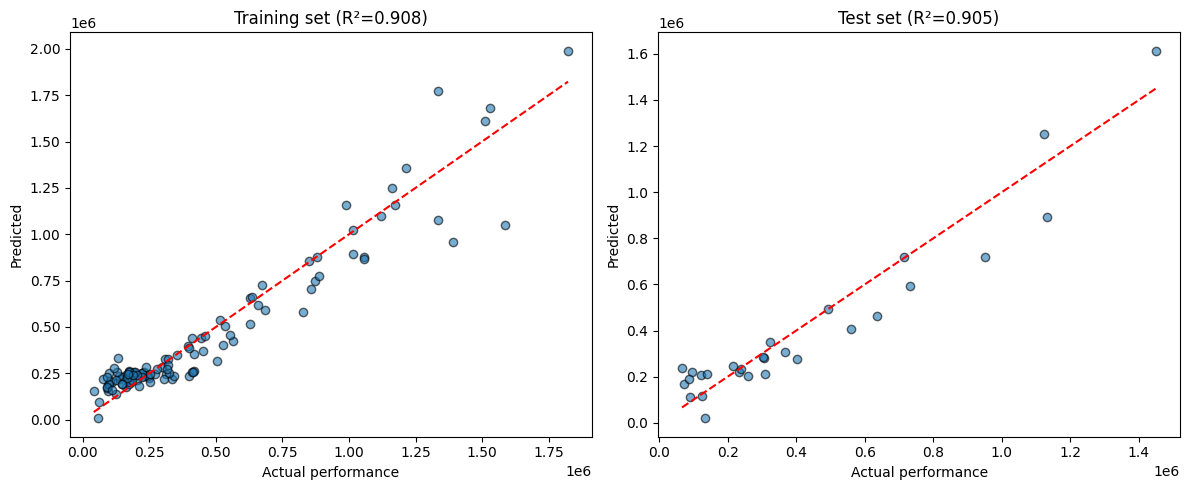

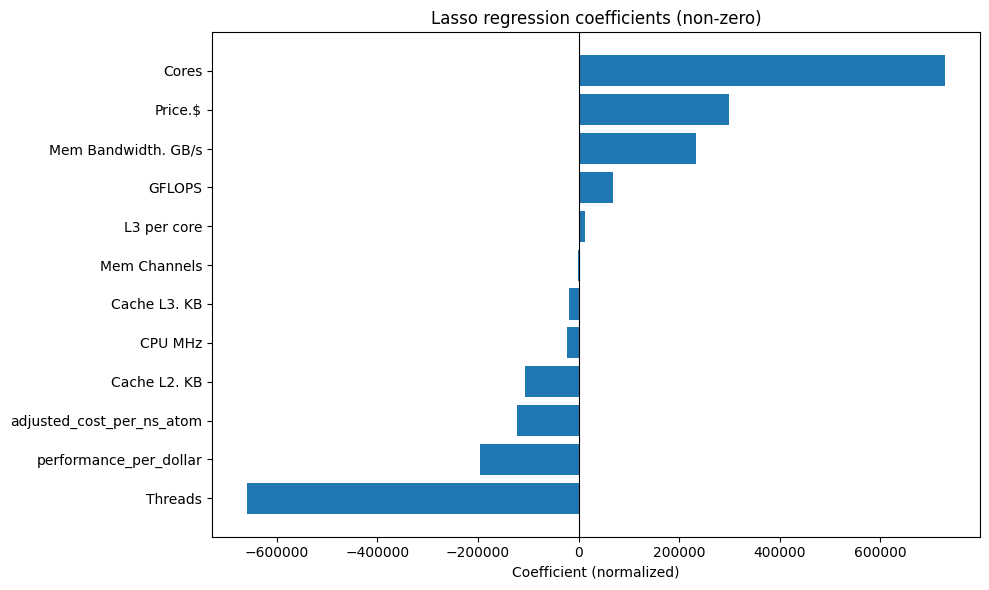


Bootstrap coefficient estimates (mean ± std):
CPU MHz             : -14314.5083 ± 21210.9962
Cache L3. KB        : 11849.3491 ± 68881.6899
Cache L2. KB        : -47068.8566 ± 105090.4953
Cores               : 386239.7677 ± 559561.3972
Threads             : -320240.9364 ± 529284.1725
Mem Bandwidth. GB/s : 146588.3272 ± 168143.7649
GFLOPS              : 81121.9481 ± 101467.8093
Mem Channels        : 18446.7982 ± 70206.7123
Price.$             : 273887.1303 ± 129981.8027
performance_per_dollar: -289711761.1868 ± 1313389217.2322
adjusted_cost_per_ns_atom: -122343.3122 ± 63262.2842
L3 per core         : 8186.0369 ± 16228.0803


In [ ]:
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 1. Data preparation (using processor.X)
# ------------------------------
# Target variable
target = 'Natoms*ns/day'

# Features – all numeric columns from processor.features that are present in X
features = [col for col in processor.features if col in processor.X.columns and col != target]

# Build dataframe
X_data = processor.X[features].copy()
y_data = processor.X[target].copy()

# Replace inf, -inf, drop rows with NaN
X_data = X_data.replace([np.inf, -np.inf], np.nan)
y_data = y_data.replace([np.inf, -np.inf], np.nan)
valid_mask = X_data.notna().all(axis=1) & y_data.notna()
X_data = X_data[valid_mask]
y_data = y_data[valid_mask]

print(f"Total observations after cleaning: {len(X_data)}")

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42
)

# Normalization (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# 2. Alpha selection with LassoCV (cross-validation)
# ------------------------------
lasso_cv = LassoCV(
    alphas=np.logspace(-4, 1, 50),
    cv=5,
    random_state=42,
    max_iter=10000,
    n_jobs=-1
)
lasso_cv.fit(X_train_scaled, y_train)
best_alpha = lasso_cv.alpha_
print(f"\nOptimal alpha: {best_alpha:.5f}")

# ------------------------------
# 3. Final model with best alpha
# ------------------------------
lasso = Lasso(alpha=best_alpha, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = lasso.predict(X_train_scaled)
y_test_pred = lasso.predict(X_test_scaled)

# Metrics
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"R² on training: {r2_train:.3f}")
print(f"R² on test: {r2_test:.3f}")
print(f"MSE on test: {mse_test:.3e}")

# ------------------------------
# 4. Coefficient table (non-zero)
# ------------------------------
coeff = lasso.coef_
nonzero_mask = np.abs(coeff) > 1e-6
nonzero_features = np.array(features)[nonzero_mask]
nonzero_coeff = coeff[nonzero_mask]

coeff_df = pd.DataFrame({
    'Feature': nonzero_features,
    'Coefficient (normalized)': nonzero_coeff,
    'Abs impact': np.abs(nonzero_coeff)
}).sort_values('Abs impact', ascending=False)
print("\nNon-zero coefficients (normalized X):")
print(coeff_df.to_string(index=False))

# ------------------------------
# 5. Visualization
# ------------------------------
# 5.1. Predicted vs actual
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(y_train, y_train_pred, alpha=0.6, edgecolors='k')
ax[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
ax[0].set_xlabel('Actual performance')
ax[0].set_ylabel('Predicted')
ax[0].set_title(f'Training set (R²={r2_train:.3f})')

ax[1].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k')
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax[1].set_xlabel('Actual performance')
ax[1].set_ylabel('Predicted')
ax[1].set_title(f'Test set (R²={r2_test:.3f})')
plt.tight_layout()
plt.show()

# 5.2. Lasso coefficients (horizontal bar chart)
plt.figure(figsize=(10, 6))
coeff_df_sorted = coeff_df.sort_values('Coefficient (normalized)')
plt.barh(coeff_df_sorted['Feature'], coeff_df_sorted['Coefficient (normalized)'])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (normalized)')
plt.title('Lasso regression coefficients (non-zero)')
plt.tight_layout()
plt.show()

# ------------------------------
# 6. (Optional) Bootstrap for coefficient stability
# ------------------------------
def bootstrap_lasso(X, y, n_bootstrap=200, alpha=best_alpha):
    # Convert to numpy arrays for safety
    X = np.asarray(X)
    y = np.asarray(y)
    n_samples = len(X)
    coeffs_bootstrap = []
    for _ in range(n_bootstrap):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        X_bs = X[idx]
        y_bs = y[idx]
        lasso_bs = Lasso(alpha=alpha, random_state=None, max_iter=10000)
        lasso_bs.fit(X_bs, y_bs)
        coeffs_bootstrap.append(lasso_bs.coef_)
    coeffs_bootstrap = np.array(coeffs_bootstrap)
    mean_coeff = coeffs_bootstrap.mean(axis=0)
    std_coeff = coeffs_bootstrap.std(axis=0)
    return mean_coeff, std_coeff

# Call function
if len(X_train_scaled) > 30:
    mean_coef, std_coef = bootstrap_lasso(
        X_train_scaled,
        y_train.values,
        n_bootstrap=100,
        alpha=best_alpha
    )
    print("\nBootstrap coefficient estimates (mean ± std):")
    for i, f in enumerate(features):
        if np.abs(mean_coef[i]) > 1e-5:
            print(f"{f:20s}: {mean_coef[i]:.4f} ± {std_coef[i]:.4f}")

## PCA+ElasticNetCV

Total observations after cleaning: 139

Optimal alpha: 4.94171
Optimal l1_ratio: 0.900
R² on training: 0.874
R² on test: 0.842
MSE on test: 2.078e+10

Non-zero coefficients (normalized X):
               Feature  Coefficient (normalized)   Abs impact
               Price.$              68290.965601 68290.965601
                GFLOPS              56015.925377 56015.925377
          Cache L2. KB              55608.540363 55608.540363
   Mem Bandwidth. GB/s              53674.983708 53674.983708
               Threads              48803.302264 48803.302264
                 Cores              38716.859036 38716.859036
          Cache L3. KB              32937.975830 32937.975830
performance_per_dollar             -31391.661355 31391.661355
          Mem Channels              29938.959438 29938.959438


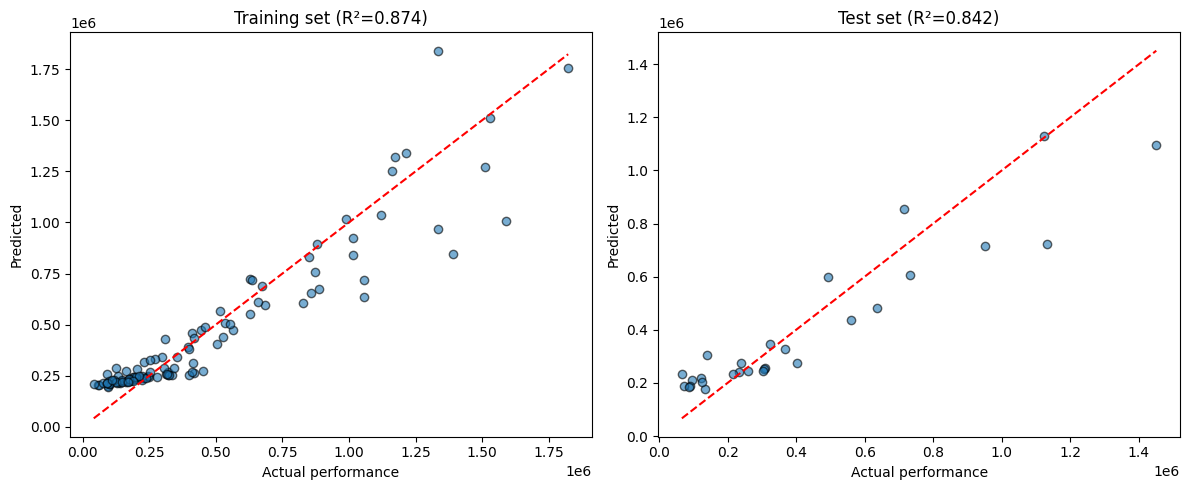

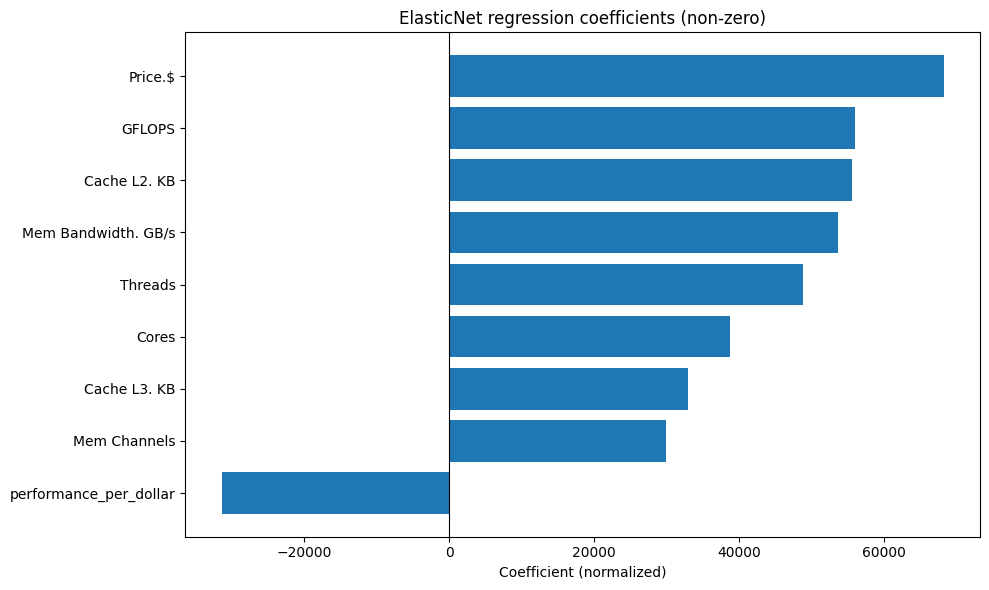


Bootstrap coefficient estimates (mean ± std) and sign stability:
Threads             : 50454.14 ± 11759.44   [stable +]
Cores               : 42272.60 ± 11327.19   [stable +]
Mem Bandwidth. GB/s : 54617.23 ±  8424.60   [stable +]
GFLOPS              : 60083.24 ± 16852.91   [stable +]
Price.$             : 64111.00 ±  7361.58   [stable +]
Cache L2. KB        : 56681.45 ±  7068.66   [stable +]
Cache L3. KB        : 33606.02 ±  8325.36   [stable +]
Mem Channels        : 30207.79 ±  8035.32   [stable +]
performance_per_dollar: -23008.15 ± 15571.07   [stable -]


In [ ]:
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 1. Data preparation (using processor.X)
# ------------------------------
target = 'Natoms*ns/day'

stable_features = ['Threads', 'Cores', 'Mem Bandwidth. GB/s', 'GFLOPS',
                   'Price.$', 'Cache L2. KB', 'Cache L3. KB', 'Mem Channels',
                   'performance_per_dollar']

X_data = processor.X[stable_features].copy()
y_data = processor.X[target].copy()

X_data = X_data.replace([np.inf, -np.inf], np.nan)
y_data = y_data.replace([np.inf, -np.inf], np.nan)
valid_mask = X_data.notna().all(axis=1) & y_data.notna()
X_data = X_data[valid_mask]
y_data = y_data[valid_mask]

print(f"Total observations after cleaning: {len(X_data)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# 2. ElasticNet parameter tuning with ElasticNetCV
# ------------------------------
alphas = np.logspace(-4, 1, 50)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]

elastic_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    random_state=42,
    max_iter=10000,
    n_jobs=-1
)
elastic_cv.fit(X_train_scaled, y_train)

best_alpha = elastic_cv.alpha_
best_l1_ratio = elastic_cv.l1_ratio_
print(f"\nOptimal alpha: {best_alpha:.5f}")
print(f"Optimal l1_ratio: {best_l1_ratio:.3f}")

# ------------------------------
# 3. Final ElasticNet model
# ------------------------------
elastic = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, random_state=42, max_iter=10000)
elastic.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = elastic.predict(X_train_scaled)
y_test_pred = elastic.predict(X_test_scaled)

# Metrics
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"R² on training: {r2_train:.3f}")
print(f"R² on test: {r2_test:.3f}")
print(f"MSE on test: {mse_test:.3e}")

# ------------------------------
# 4. Coefficient table (non-zero)
# ------------------------------
coeff = elastic.coef_
nonzero_mask = np.abs(coeff) > 1e-6
nonzero_features = np.array(stable_features)[nonzero_mask]
nonzero_coeff = coeff[nonzero_mask]

coeff_df = pd.DataFrame({
    'Feature': nonzero_features,
    'Coefficient (normalized)': nonzero_coeff,
    'Abs impact': np.abs(nonzero_coeff)
}).sort_values('Abs impact', ascending=False)
print("\nNon-zero coefficients (normalized X):")
print(coeff_df.to_string(index=False))

# ------------------------------
# 5. Visualization
# ------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(y_train, y_train_pred, alpha=0.6, edgecolors='k')
ax[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
ax[0].set_xlabel('Actual performance')
ax[0].set_ylabel('Predicted')
ax[0].set_title(f'Training set (R²={r2_train:.3f})')

ax[1].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k')
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax[1].set_xlabel('Actual performance')
ax[1].set_ylabel('Predicted')
ax[1].set_title(f'Test set (R²={r2_test:.3f})')
plt.tight_layout()
plt.show()

# Horizontal bar chart of coefficients
plt.figure(figsize=(10, 6))
coeff_df_sorted = coeff_df.sort_values('Coefficient (normalized)')
plt.barh(coeff_df_sorted['Feature'], coeff_df_sorted['Coefficient (normalized)'])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (normalized)')
plt.title('ElasticNet regression coefficients (non-zero)')
plt.tight_layout()
plt.show()

# ------------------------------
# 6. Bootstrap for coefficient stability
# ------------------------------
def bootstrap_elasticnet(X, y, n_bootstrap=200, alpha=best_alpha, l1_ratio=best_l1_ratio):
    X = np.asarray(X)
    y = np.asarray(y)
    n_samples = len(X)
    coeffs_bootstrap = []
    for _ in range(n_bootstrap):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        X_bs = X[idx]
        y_bs = y[idx]
        en_bs = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=None, max_iter=10000)
        en_bs.fit(X_bs, y_bs)
        coeffs_bootstrap.append(en_bs.coef_)
    coeffs_bootstrap = np.array(coeffs_bootstrap)
    mean_coeff = coeffs_bootstrap.mean(axis=0)
    std_coeff = coeffs_bootstrap.std(axis=0)
    sign_stability = (coeffs_bootstrap > 0).mean(axis=0)
    return mean_coeff, std_coeff, sign_stability

if len(X_train_scaled) > 30:
    mean_coef, std_coef, sign_stab = bootstrap_elasticnet(
        X_train_scaled,
        y_train.values,
        n_bootstrap=100,
        alpha=best_alpha,
        l1_ratio=best_l1_ratio
    )
    print("\nBootstrap coefficient estimates (mean ± std) and sign stability:")
    for i, f in enumerate(stable_features):
        if np.abs(mean_coef[i]) > 1e-5:
            sign_text = "stable +" if sign_stab[i] > 0.95 else ("stable -" if sign_stab[i] < 0.05 else f"unstable ({sign_stab[i]:.2f})")
            print(f"{f:20s}: {mean_coef[i]:8.2f} ± {std_coef[i]:8.2f}   [{sign_text}]")

# Random Forest

Total observations after cleaning: 139

Best hyperparameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}
Best cross-validation R²: 0.950
R² on training: 0.994
R² on test: 0.978
MSE on test: 2.860e+09

Random Forest feature importance:
                  Feature  Importance
      Mem Bandwidth. GB/s    0.220940
                   GFLOPS    0.196118
                  Price.$    0.119799
                    Cores    0.111273
                  Threads    0.108560
             Cache L2. KB    0.108339
             Cache L3. KB    0.087077
             Mem Channels    0.017777
   performance_per_dollar    0.011168
adjusted_cost_per_ns_atom    0.010140
                  CPU MHz    0.004420
              L3 per core    0.004390


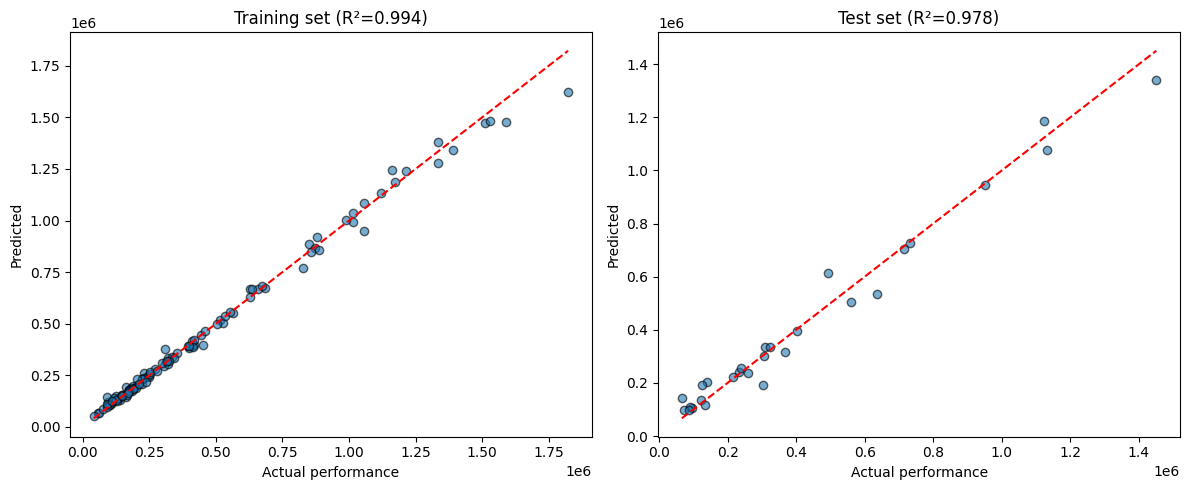

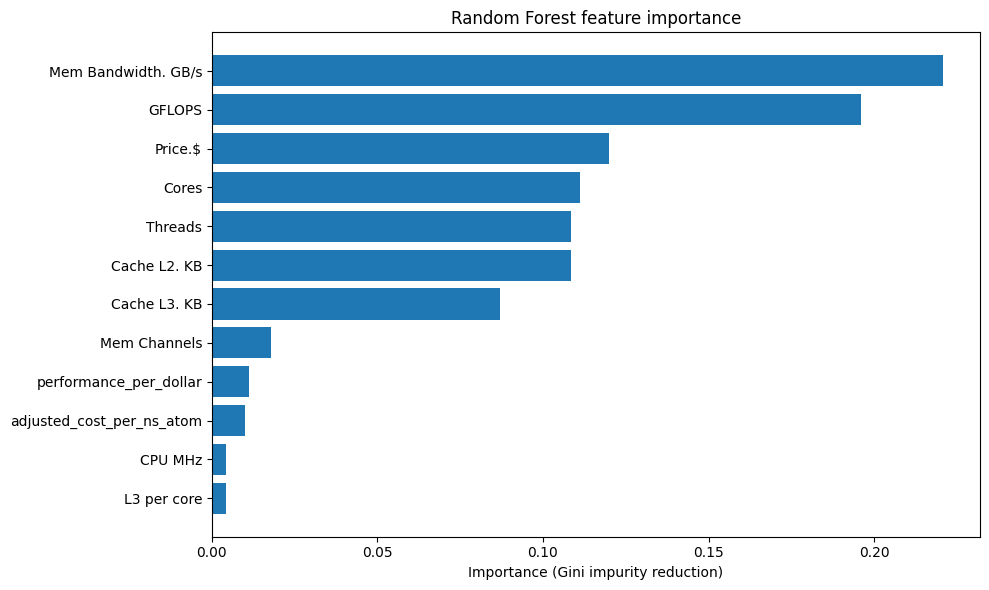

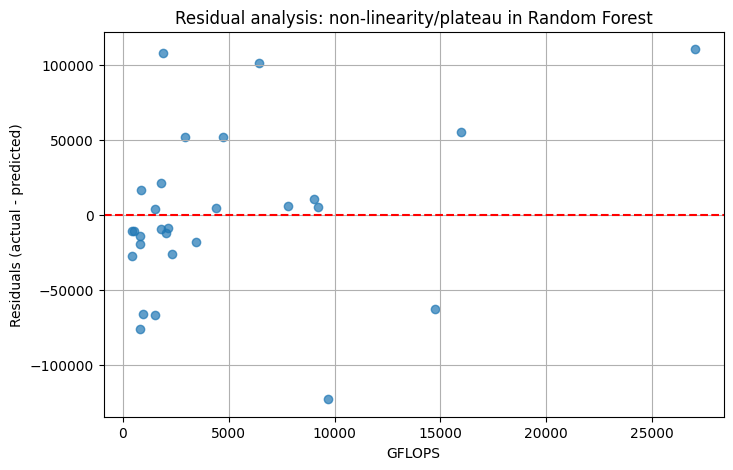


Stability of feature importance (mean ± std):
CPU MHz                  : 0.0058 ± 0.0016
Cache L3. KB             : 0.0879 ± 0.0302
Cache L2. KB             : 0.1215 ± 0.0425
Cores                    : 0.1228 ± 0.0288
Threads                  : 0.1248 ± 0.0339
Mem Bandwidth. GB/s      : 0.1718 ± 0.0403
GFLOPS                   : 0.1866 ± 0.0311
Mem Channels             : 0.0329 ± 0.0142
Price.$                  : 0.1135 ± 0.0440
performance_per_dollar   : 0.0162 ± 0.0051
adjusted_cost_per_ns_atom: 0.0116 ± 0.0043
L3 per core              : 0.0046 ± 0.0013


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 1. Data preparation (using processor.X)
# ------------------------------
processor = BenchmarkDataProcessor(filepath,
    packets=['LAMMPS_23Jun2022'],
    benchmarks=['Model_20k_Atoms'],
    processor_filter_keywords=['Intel Atom', 'Intel Pentium', 'Intel Celeron', 'Intel Core',
            'Intel Xeon', 'Apple', 'Ampere', 'ARM', 'AMD Athlon', 'AMD EPYC',
            'AMD Ryzen', 'AMD Opteron', '2 x AMD', '2 x Intel', '4 x '
]
)
processor.prepare_data(
  x_axis_param='GFLOPS',
  use_all_values=True,
  x_axis_range=(100, 5000)
)

target = 'Natoms*ns/day'

# Use all features
stable_features = [col for col in processor.features if col in processor.X.columns and col != target]

X_data = processor.X[stable_features].copy()
y_data = processor.X[target].copy()

X_data = X_data.replace([np.inf, -np.inf], np.nan)
y_data = y_data.replace([np.inf, -np.inf], np.nan)
valid_mask = X_data.notna().all(axis=1) & y_data.notna()
X_data = X_data[valid_mask]
y_data = y_data[valid_mask]

print(f"Total observations after cleaning: {len(X_data)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42
)

# For Random Forest scaling is not required (insensitive to scale), but we keep it for uniformity
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# 2. Hyperparameter tuning with RandomizedSearchCV
# ------------------------------
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
rf_random.fit(X_train_scaled, y_train)

best_rf = rf_random.best_estimator_
print(f"\nBest hyperparameters: {rf_random.best_params_}")
print(f"Best cross-validation R²: {rf_random.best_score_:.3f}")

# ------------------------------
# 3. Evaluation on test set
# ------------------------------
y_train_pred = best_rf.predict(X_train_scaled)
y_test_pred = best_rf.predict(X_test_scaled)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"R² on training: {r2_train:.3f}")
print(f"R² on test: {r2_test:.3f}")
print(f"MSE on test: {mse_test:.3e}")

# ------------------------------
# 4. Feature importance (Gini importance)
# ------------------------------
feature_importance = best_rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': stable_features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nRandom Forest feature importance:")
print(importance_df.to_string(index=False))

# ------------------------------
# 5. Visualization
# ------------------------------
# Predicted vs actual
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(y_train, y_train_pred, alpha=0.6, edgecolors='k')
ax[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
ax[0].set_xlabel('Actual performance')
ax[0].set_ylabel('Predicted')
ax[0].set_title(f'Training set (R²={r2_train:.3f})')

ax[1].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k')
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax[1].set_xlabel('Actual performance')
ax[1].set_ylabel('Predicted')
ax[1].set_title(f'Test set (R²={r2_test:.3f})')
plt.tight_layout()
plt.show()

# Horizontal bar chart of feature importance
plt.figure(figsize=(10, 6))
importance_df_sorted = importance_df.sort_values('Importance')
plt.barh(importance_df_sorted['Feature'], importance_df_sorted['Importance'])
plt.xlabel('Importance (Gini impurity reduction)')
plt.title('Random Forest feature importance')
plt.tight_layout()
plt.show()

# ------------------------------
# 6. Residual analysis relative to GFLOPS to check for plateau
# ------------------------------
residuals = y_test - y_test_pred
plt.figure(figsize=(8,5))
plt.scatter(X_test['GFLOPS'], residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('GFLOPS')
plt.ylabel('Residuals (actual - predicted)')
plt.title('Residual analysis: non-linearity/plateau in Random Forest')
plt.grid(True)
plt.show()

# ------------------------------
# 7. (Optional) Bootstrap for feature importance stability
# ------------------------------
def bootstrap_rf_importance(X, y, n_bootstrap=50, base_rf=best_rf):
    X = np.asarray(X)
    y = np.asarray(y)
    n_samples = len(X)
    all_importances = []
    for _ in range(n_bootstrap):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        X_bs, y_bs = X[idx], y[idx]
        rf_bs = RandomForestRegressor(
            n_estimators=base_rf.n_estimators,
            max_depth=base_rf.max_depth,
            min_samples_split=base_rf.min_samples_split,
            min_samples_leaf=base_rf.min_samples_leaf,
            max_features=base_rf.max_features,
            random_state=None,
            n_jobs=-1
        )
        rf_bs.fit(X_bs, y_bs)
        all_importances.append(rf_bs.feature_importances_)
    all_importances = np.array(all_importances)
    mean_imp = all_importances.mean(axis=0)
    std_imp = all_importances.std(axis=0)
    return mean_imp, std_imp

if len(X_train_scaled) > 30:
    mean_imp, std_imp = bootstrap_rf_importance(X_train_scaled, y_train.values, n_bootstrap=50, base_rf=best_rf)
    print("\nStability of feature importance (mean ± std):")
    for i, f in enumerate(stable_features):
        print(f"{f:25s}: {mean_imp[i]:.4f} ± {std_imp[i]:.4f}")

# ------------------------------
# 8. Prediction for a new CPU (example)
# ------------------------------
# Save model (optional)
# import joblib
# joblib.dump(best_rf, 'random_forest_model.pkl')
# joblib.dump(scaler, 'scaler_rf.pkl')

# Example new CPU:
# new_cpu = np.array([[32, 16, 150.0, 45000, 6000.0, 2048, 4096, 8, 7.5]])
# new_cpu_scaled = scaler.transform(new_cpu)
# pred = best_rf.predict(new_cpu_scaled)[0]
# print(f"\nPredicted performance: {pred:.2e} Natoms*ns/day")

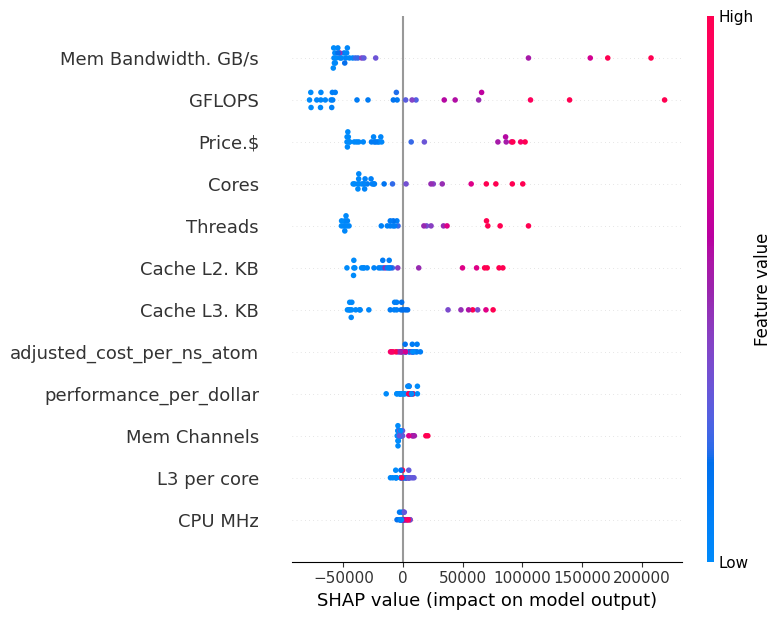

In [14]:
import shap

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=stable_features)